
  DAC SYSTEM V13.2 — Variable Volume + Activity + Sizing
  Ref: Shu(2020), Newman(2004), Pintauro(1984), Pitzer(1991)

  Absorber: 200L, 40L/min
    Pass   500: NaOH=1.7468, Na2CO3=0.1266, t=41.7h
    Pass  1000: NaOH=1.4956, Na2CO3=0.2522, t=83.3h
    Pass  1500: NaOH=1.2467, Na2CO3=0.3767, t=125.0h
    Pass  2000: NaOH=1.0008, Na2CO3=0.4996, t=166.7h
    Pass  2500: NaOH=0.7589, Na2CO3=0.6206, t=208.3h
    Pass  3000: NaOH=0.5228, Na2CO3=0.7386, t=250.0h
    Pass  3500: NaOH=0.2961, Na2CO3=0.8519, t=291.7h

  ABSORBER: 3973 passes | 331.1h (13.8d)
    NaOH: 2.000 -> 0.0998M
    Na2CO3: 0 -> 0.9501M
    CO2: 190.0 mol (8361g)

  -- Iteration 1 --

  EC Cell V13.2: 7x500cm2 | j=95.5A/m2 | pH_stop=5.0
    Feed: 0.9501M Na2CO3 + 0.0998M NaOH
    V_acid=199.2L | V_base=200.6L (variable)
    CEM: Nernst-Planck, d=178um, Q=1.2
    -> pH-stop at 320.4h
    t_abs=331.1h | t_EC=320.4h | mismatch=-3.2%
    j: 95.5 -> 92.4

  -- Iteration 2 --

  EC Cell V13.2: 7x500cm2 | j=92.4A/m2 | pH_stop=5

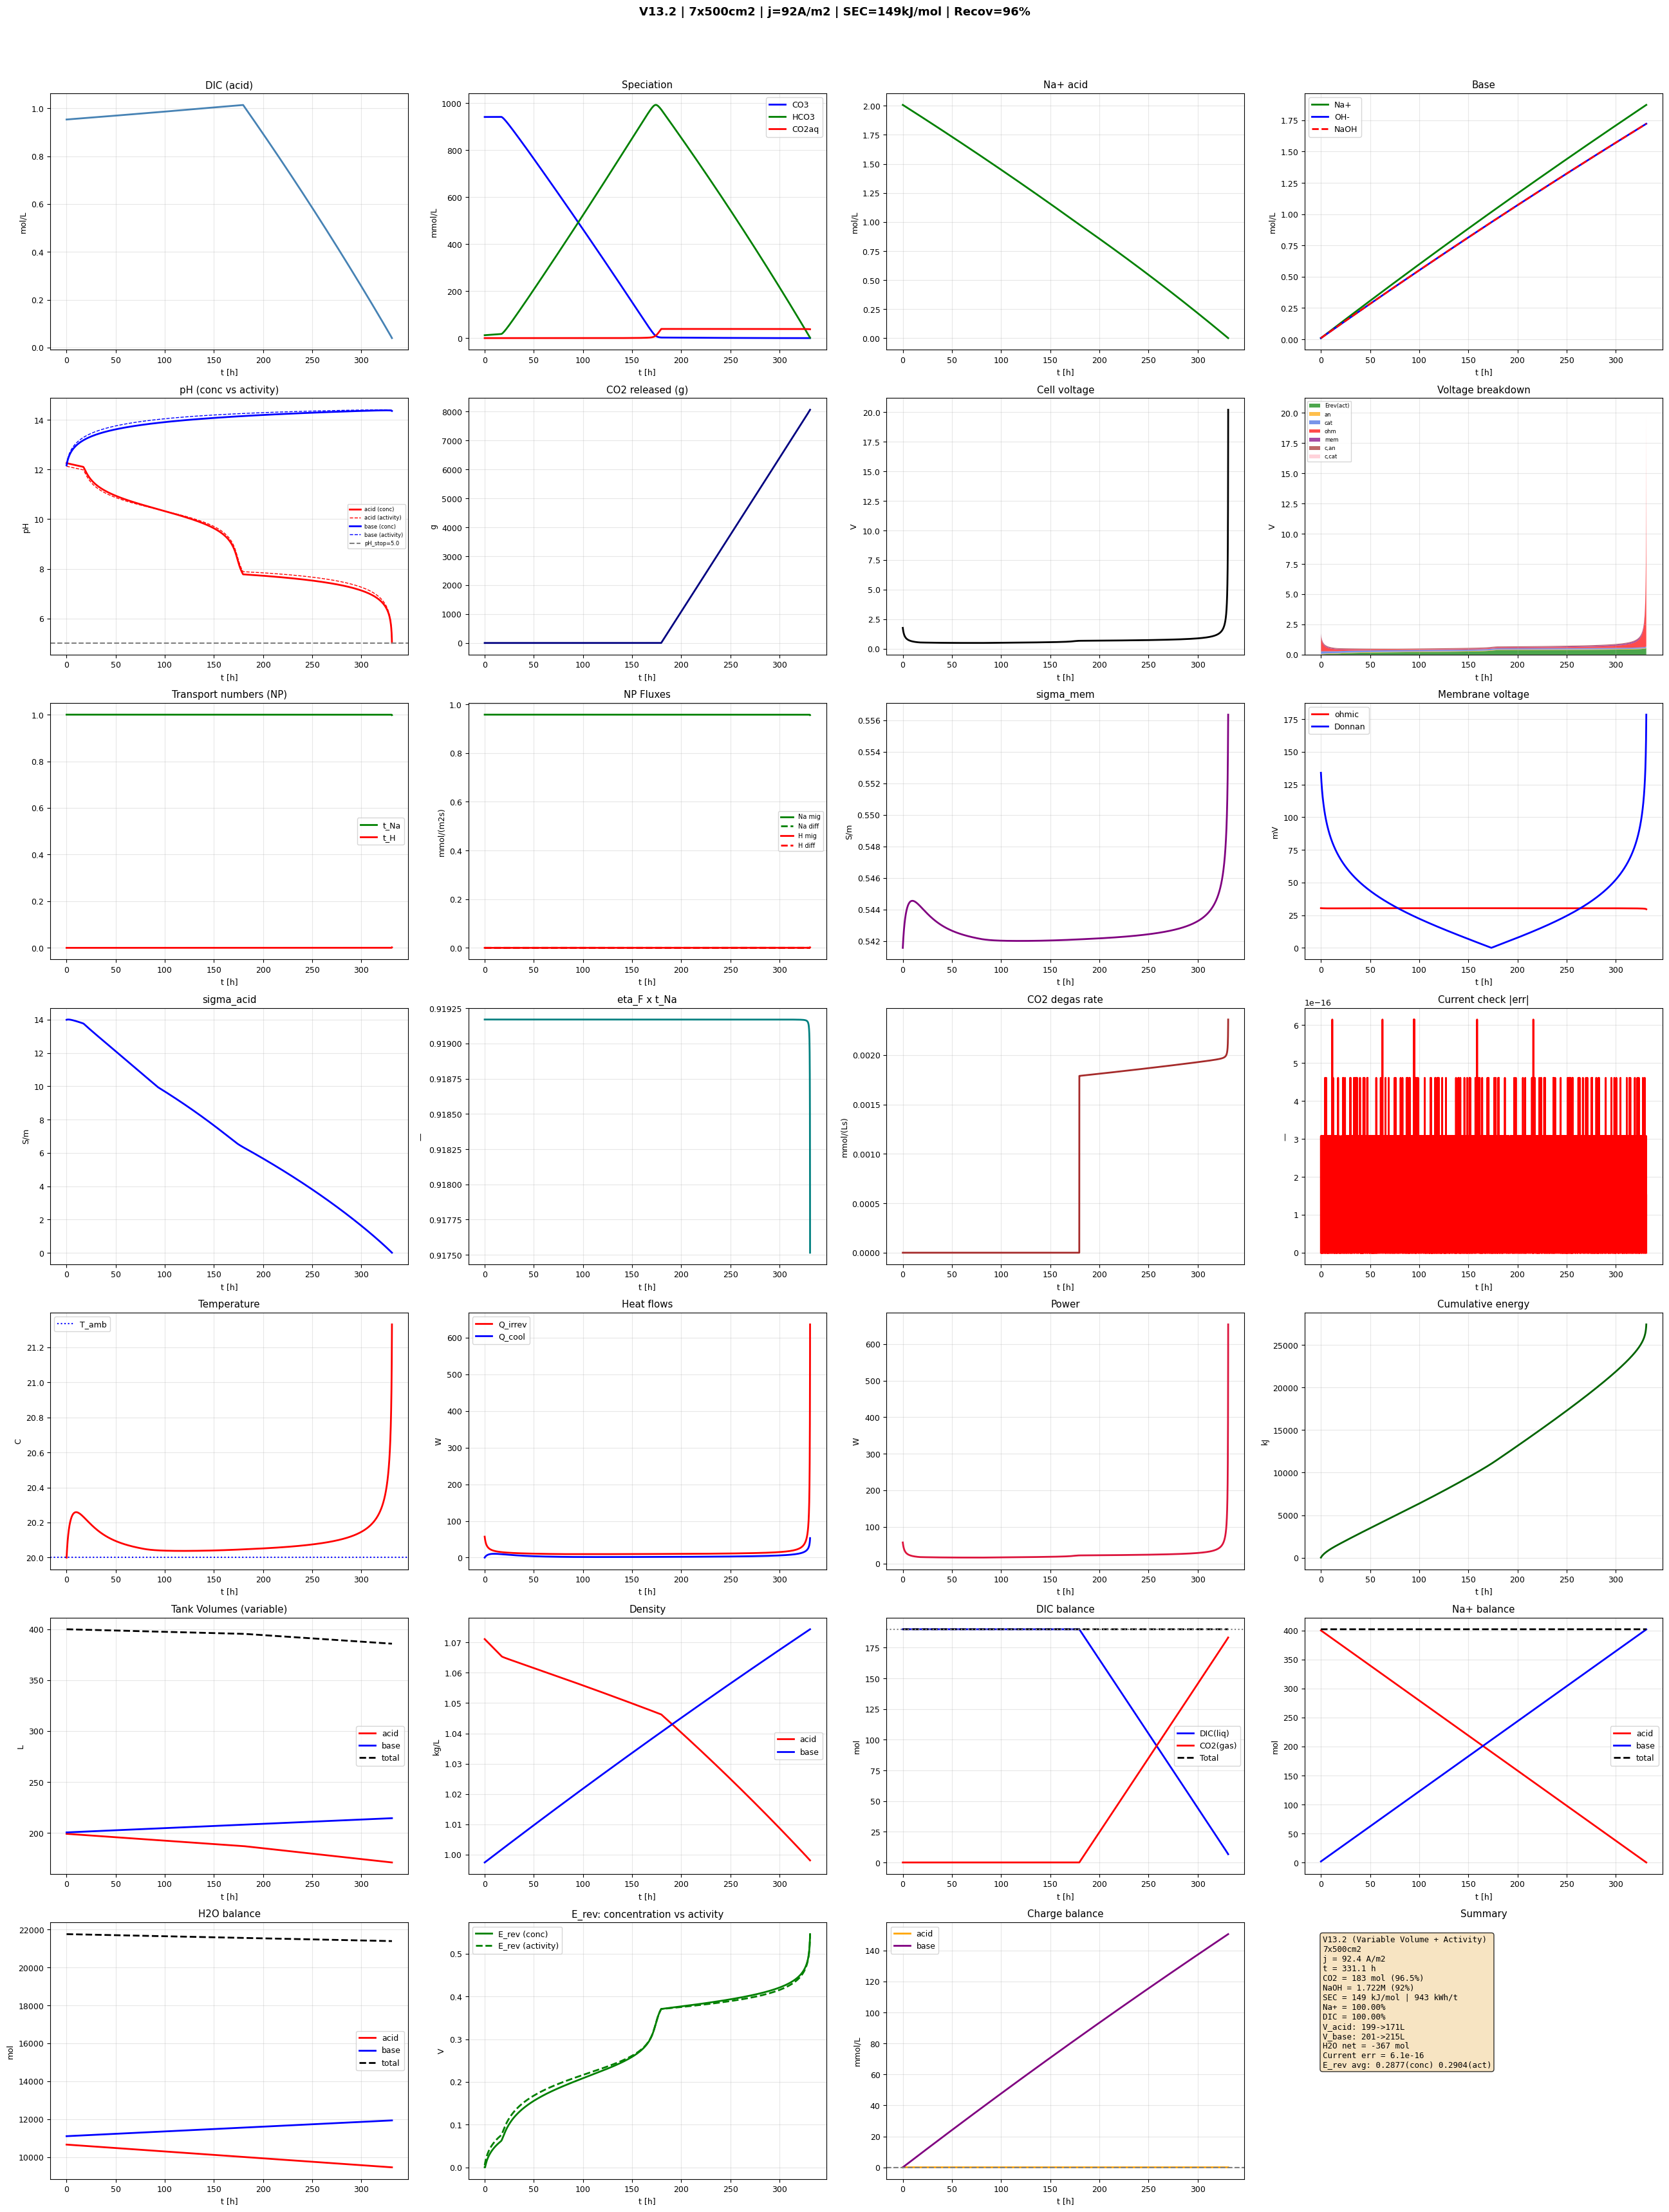

In [ ]:
"""
=============================================================================
 DAC SYSTEM — ELECTROCHEMICAL CELL MODEL
=============================================================================

 Ref: Shu et al. (2020), Newman (2004), Pintauro & Bennion (1984)
      Pitzer (1991) Activity Coefficients in Electrolyte Solutions
      Davies (1962) Ion Association

=============================================================================
"""

import numpy as np
from scipy.integrate import solve_ivp, trapezoid
from scipy.optimize import brentq
from scipy.constants import R as R_gas

F = 96485.0
R = R_gas
MW_H2O = 18.015e-3   # kg/mol
MW_H2O_g = 18.015    # g/mol


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SECTION 1: PROPERTY MODELS                                         ║
# ╚═══════════════════════════════════════════════════════════════════════╝

class IonDB:
    D_25 = {'Na+':1.334e-9,'H+':9.311e-9,'OH-':5.273e-9,
            'CO3':0.923e-9,'HCO3':1.185e-9,'CO2aq':1.91e-9}
    z = {'Na+':1,'H+':1,'OH-':-1,'CO3':-2,'HCO3':-1,'CO2aq':0}
    D_mem_frac = {'Na+':0.10,'H+':0.10,'OH-':0.01,'CO3':0.005}
    lam_25 = {'Na+':50.11e-4,'H+':349.81e-4,'OH-':198.3e-4,
              'CO3':138.6e-4,'HCO3':44.5e-4}
    MW = {'Na+':23.0,'H+':1.008,'OH-':17.01,'CO3':60.01,
          'HCO3':61.02,'CO2':44.01,'NaOH':40.0,'Na2CO3':106.0,
          'H2':2.016,'H2O':18.015}
    # Partial molar volumes [L/mol] at 25°C
    # Ref: Millero (1971) Chem. Rev. 71, 147
    Vm = {'Na+':0.00112,'H+':0.0,'OH-':-0.00418,'CO3':-0.00614,
          'HCO3':0.02413,'CO2':0.03260,'Na2CO3':0.02660,
          'NaOH':-0.00520,'H2O':0.01807}

    @staticmethod
    def D(ion, T=298.15):
        return IonDB.D_25[ion]*(T/298.15)*np.exp(1825*(1/298.15-1/T))
    @staticmethod
    def lam(ion, T=298.15):
        if ion not in IonDB.lam_25: return 0.0
        return IonDB.lam_25[ion]*(T/298.15)*np.exp(1825*(1/298.15-1/T))


class Thermo:
    @staticmethod
    def K1(T): return 10**-(3404.71/T+0.03279*T-14.8435)
    @staticmethod
    def K2(T): return 10**-(2902.39/T+0.02379*T-6.4980)
    @staticmethod
    def Kw(T): return 10**-(4470.99/T+0.01706*T-6.0846)
    @staticmethod
    def H_CO2(T): return 3.4e-2*np.exp(2400*(1/T-1/298.15))
    @staticmethod
    def Cp_solution(c=1.0): return 4186.0*max(1-0.07*min(c,5),0.7)

    @staticmethod
    def volume_acid(n_H2O, n_Na, n_DIC):
        """Acid tank volume [L] from moles. Uses partial molar volumes."""
        V = n_H2O * IonDB.Vm['H2O']  # water
        V += n_Na * IonDB.Vm['Na+']   # Na+ (with counter-ion volume implicit)
        V += n_DIC * IonDB.Vm['CO2']  # approximate DIC as CO2 volume
        return max(V, 1.0)

    @staticmethod
    def volume_base(n_H2O, n_Na, n_OH):
        """Base tank volume [L] from moles."""
        V = n_H2O * IonDB.Vm['H2O']
        V += n_Na * IonDB.Vm['Na+']
        V += n_OH * IonDB.Vm['OH-']
        return max(V, 1.0)

    @staticmethod
    def density(V_L, n_H2O, n_solute_mass_g):
        """Solution density [kg/L]."""
        m_total = n_H2O * MW_H2O_g / 1000 + n_solute_mass_g / 1000
        return m_total / max(V_L, 0.001)


class ActivityCoeff:
    """
    Davies equation for activity coefficients.
    log(gamma_i) = -A z_i^2 (sqrt(I)/(1+sqrt(I)) - 0.3I)
    where A = 0.509 at 25°C
    Ref: Davies (1962); Stumm & Morgan Ch. 3
    """
    @staticmethod
    def A_DH(T=298.15):
        """Debye-Hückel A parameter. Ref: Robinson & Stokes, App. 7.1."""
        return 0.509 * (298.15/T)**0.5 * (78.4*298.15/(78.4*T))**1.5

    @staticmethod
    def gamma(z, I, T=298.15):
        """Single-ion activity coefficient."""
        A = ActivityCoeff.A_DH(T)
        sqI = np.sqrt(min(I, 6.0))
        log_g = -A * z**2 * (sqI/(1+sqI) - 0.3*min(I, 6.0))
        return 10**log_g

    @staticmethod
    def ionic_strength(concs):
        """I = 0.5 × Σ c_i z_i². concs = dict of {ion: concentration}."""
        return sum(0.5*c*IonDB.z.get(k,0)**2 for k,c in concs.items() if k in IonDB.z)


class Speciation:
    def __init__(self, T=293.15): self.update_T(T)
    def update_T(self, T):
        self.T = T; self.K1 = Thermo.K1(T)
        self.K2 = Thermo.K2(T); self.Kw = Thermo.Kw(T)

    def acid(self, C_DIC, c_Na, c_OH_free=0, use_activity=True):
        """Speciation with optional activity correction."""
        C = max(C_DIC, 1e-15); cNa = max(c_Na, 0); cOHf = max(c_OH_free, 0)
        K1, K2, Kw = self.K1, self.K2, self.Kw

        def cb(lh):
            h = 10**lh; oh = Kw/h
            d = 1 + K1/h + K1*K2/h**2
            co2 = C/d; hco3 = co2*K1/h; co3 = hco3*K2/h
            return (cNa + h) - (oh + cOHf + hco3 + 2*co3)

        try: h = 10**brentq(cb, -15, 2, xtol=1e-12)
        except: h = Kw/max(cOHf, 1e-12) if cOHf > 0.01 else 1e-7
        oh = Kw/h; d = 1+K1/h+K1*K2/h**2
        co2 = C/d; hco3 = co2*K1/h; co3 = hco3*K2/h
        pH = -np.log10(max(h, 1e-15))

        # Activity correction for E_rev
        if use_activity:
            concs = {'Na+':cNa,'H+':h,'OH-':oh,'CO3':co3,'HCO3':hco3}
            I = ActivityCoeff.ionic_strength(concs)
            gamma_H = ActivityCoeff.gamma(1, I, self.T)
            a_H = h * gamma_H
            pH_activity = -np.log10(max(a_H, 1e-15))
        else:
            pH_activity = pH

        return co3, hco3, co2, h, oh, pH, pH_activity

    def base_full(self, c_Na, c_OH, use_activity=True):
        oh = max(c_OH, 1e-12); h = self.Kw/oh
        c_NaOH = min(max(c_Na, 0), max(c_OH, 0))
        pH = -np.log10(max(h, 1e-15))
        if use_activity:
            I = 0.5*(c_Na + oh)
            gamma_H = ActivityCoeff.gamma(1, I, self.T)
            gamma_OH = ActivityCoeff.gamma(1, I, self.T)
            a_H = h * gamma_H
            pH_activity = -np.log10(max(a_H, 1e-15))
        else:
            pH_activity = pH
        return c_NaOH, oh, h, pH, pH_activity


class Conductivity:
    @staticmethod
    def compute(concs, T=293.15):
        Is = sum(0.5*c*IonDB.z.get(k,0)**2 for k,c in concs.items() if k in IonDB.z)
        s = 0
        for k,c in concs.items():
            l = IonDB.lam(k, T)
            if l > 0 and c > 0:
                s += l*c*1000*max(1-0.23*np.sqrt(min(Is,2)),0.3)
        return max(s, 0.001)


class CO2Degas:
    def __init__(self, kLa=0.05, P=1.0): self.kLa = kLa; self.P = P
    def rate(self, c, T): return self.kLa*max(c-Thermo.H_CO2(T)*self.P, 0)


class ThermalModel:
    def __init__(self, Ta=293.15, U=20, Ae=2.0):
        self.Ta = Ta; self.U = U; self.Ae = Ae; self.dS = -80.7
    def dT_dt(self, T, I, eta, m_a_kg, m_b_kg, Cp_a, Cp_b):
        mCp = m_a_kg*Cp_a + m_b_kg*Cp_b
        return (I*eta + I*T*self.dS/F - self.U*self.Ae*(T-self.Ta))/mCp


class Electrodes:
    def __init__(self, j0_an=50, j0_cat=10, alpha=0.5, T_ref=293.15,
                 Ea_an=12000, Ea_cat=30000, dBL=50e-6):
        self.j0_an=j0_an;self.j0_cat=j0_cat;self.alpha=alpha
        self.T_ref=T_ref;self.Ea_an=Ea_an;self.Ea_cat=Ea_cat;self.dBL=dBL
    def _j0(self,j0r,Ea,T): return j0r*np.exp(-Ea/R*(1/T-1/self.T_ref))
    def _eta_BV(self,j,j0,a,T):
        if abs(j)<1e-12: return 0.0
        nFRT=F/(R*T)
        try: return brentq(lambda e:j0*(np.exp(a*nFRT*e)-np.exp(-(1-a)*nFRT*e))-abs(j),0,3,xtol=1e-10)
        except: return R*T/(a*F)*np.log(max(abs(j)/j0,1))
    def anode(self,j,T): return self._eta_BV(j,self._j0(self.j0_an,self.Ea_an,T),self.alpha,T)
    def cathode(self,j,T,cOH=1.0):
        return self._eta_BV(j,self._j0(self.j0_cat,self.Ea_cat,T)*max(cOH,0.01)**0.5,self.alpha,T)
    def conc_anode(self,j,c_H2,T):
        jl=2*F*4.5e-9*(T/298.15)*max(c_H2,1e-6)*1000/self.dBL
        return -(R*T/(2*F))*np.log(1-min(abs(j)/max(jl,1e-6),0.99))
    def conc_cathode(self,j,c_OH,T):
        return min((R*T/F)*np.log(1+abs(j)*self.dBL/(F*IonDB.D('OH-',T)*max(c_OH,0.001)*1000)),0.2)


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SECTION 2: NERNST-PLANCK CEM                                         ║
# ╚═══════════════════════════════════════════════════════════════════════╝

class NernstPlanckCEM:
    def __init__(self, d=178e-6, Q=1.2, T=293.15, n_drag=3.0):
        self.d = d; self.Q = abs(Q); self.T = T; self.n_drag = n_drag

    def _donnan(self, cNa, cH):
        total = max(cNa+cH, 1e-15)
        return self.Q*cNa/total, self.Q*cH/total

    def solve(self, c_acid, c_base, j, T=None):
        if T is None: T = self.T
        cNa_a=max(c_acid.get('Na+',1e-8),1e-8)
        cH_a=max(c_acid.get('H+',1e-12),1e-12)
        cNa_b=max(c_base.get('Na+',1e-8),1e-8)
        cH_b=max(c_base.get('H+',1e-12),1e-12)

        D_Na=IonDB.D('Na+',T)*IonDB.D_mem_frac['Na+']
        D_H=IonDB.D('H+',T)*IonDB.D_mem_frac['H+']
        Na_0,H_0=self._donnan(cNa_a,cH_a)
        Na_d,H_d=self._donnan(cNa_b,cH_b)
        d=self.d

        def log_mean(a,b):
            a=max(a,1e-15);b=max(b,1e-15)
            if abs(a-b)/max(a,b)<1e-6: return 0.5*(a+b)
            return (b-a)/np.log(b/a)

        Na_lm=log_mean(Na_0,Na_d); H_lm=log_mean(H_0,H_d)
        J_Na_diff=-D_Na*(Na_d-Na_0)/d; J_H_diff=-D_H*(H_d-H_0)/d
        kappa_m=D_Na*Na_lm+D_H*H_lm
        mig_needed=j/F-(J_Na_diff+J_H_diff)

        if abs(kappa_m)>1e-30:
            neg_dphi_d=mig_needed*R*T/(F*kappa_m*1000)
        else: neg_dphi_d=0

        V_ohm=neg_dphi_d*d
        J_Na_mig=D_Na*Na_lm*1000*F/(R*T)*neg_dphi_d
        J_H_mig=D_H*H_lm*1000*F/(R*T)*neg_dphi_d
        J_Na=J_Na_diff+J_Na_mig; J_H=J_H_diff+J_H_mig

        Jt=J_Na+J_H
        t_Na=J_Na/max(abs(Jt),1e-30) if Jt>0 else 0
        t_H=J_H/max(abs(Jt),1e-30) if Jt>0 else 0

        V_don_a=-(R*T/F)*np.log(self.Q/max(cNa_a+cH_a,1e-10))
        V_don_b=-(R*T/F)*np.log(self.Q/max(cNa_b+cH_b,1e-10))
        V_don=V_don_b-V_don_a
        sigma=kappa_m*1000*F**2/(R*T); sigma=max(sigma,0.01)
        J_H2O=self.n_drag*max(J_Na+J_H,0)

        return {'J_Na':J_Na,'J_H':J_H,'J_Na_mig':J_Na_mig,'J_Na_diff':J_Na_diff,
                'J_H_mig':J_H_mig,'J_H_diff':J_H_diff,'J_H2O_drag':J_H2O,
                't_Na':t_Na,'t_H':t_H,'V_mem':V_ohm+V_don,
                'V_mem_ohmic':V_ohm,'V_don':V_don,'sigma_mem':sigma}

    def verify_current(self,res,j):
        return abs((res['J_Na']+res['J_H'])*F-j)/max(abs(j),1e-10)


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SECTION 3: EQUIPMENT SIZING                                          ║
# ╚═══════════════════════════════════════════════════════════════════════╝

class Materials:
    electrode_thickness=0.5e-3; electrode_density=4500; Pt_loading=0.5e-3
    membrane_thickness=178e-6; membrane_dry_weight=0.360
    bipolar_thickness=2.0e-3; bipolar_density=2200
    gasket_density=1400; endplate_thickness=25e-3; endplate_density=7800


class Hydraulics:
    @staticmethod
    def channel_dims(A,ar=1.414): H=np.sqrt(A/ar); return ar*H,H
    @staticmethod
    def velocity(Q,W,g): return Q/max(W*g,1e-10)
    @staticmethod
    def hyd_diameter(W,g): return 2*W*g/(W+g)
    @staticmethod
    def reynolds(v,dh,rho=1050,mu=1.2e-3): return rho*v*dh/mu
    @staticmethod
    def dp_channel(v,L,dh,rho=1050,mu=1.2e-3,sf=3.0):
        Re=rho*v*dh/mu
        if Re<1: return 0.0
        f=(64/Re if Re<2300 else 0.316*Re**(-0.25))*sf
        return f*(L/dh)*0.5*rho*v**2
    @staticmethod
    def dp_manifold(Q,N,D=0.05):
        v=Q/(np.pi*(D/2)**2); return 0.5*1050*v**2*10
    @staticmethod
    def pipe_diameter(Q_m3s, v_max=2.0):
        """Pipe ID [m] for max velocity. Ref: Perry's, Table 6-1."""
        A = Q_m3s / v_max
        return np.sqrt(4*A/np.pi)


class CellStack:
    def __init__(self, N, A, ga, gb, dm=178e-6):
        self.N=N;self.A_cell=A;self.gap_a=ga;self.gap_b=gb
        self.W,self.H=Hydraulics.channel_dims(A)
        self.W_frame=self.W+0.04;self.H_frame=self.H+0.04
        M=Materials
        tp=M.electrode_thickness+ga+dm+gb+M.bipolar_thickness
        self.L_stack=N*tp+2*M.endplate_thickness+M.electrode_thickness
        self.V_acid_int=N*A*ga*1000; self.V_base_int=N*A*gb*1000
        self.A_mem_total=N*A
        self.m_electrodes=(N+1)*A*M.electrode_thickness*M.electrode_density
        self.m_membranes=N*A*M.membrane_dry_weight
        self.m_bipolar=max(N-1,0)*A*M.bipolar_thickness*M.bipolar_density
        self.m_gaskets=N*2*A*ga*M.gasket_density*0.15
        self.m_endplates=2*self.W_frame*self.H_frame*M.endplate_thickness*M.endplate_density
        self.m_Pt=(N+1)*A*M.Pt_loading
        self.m_dry=self.m_electrodes+self.m_membranes+self.m_bipolar+self.m_gaskets+self.m_endplates
        self.m_wet=self.m_dry+(self.V_acid_int+self.V_base_int)*1.05


class Tank:
    """Cylindrical tank sizing. Ref: Walas (1990) Chemical Process Equipment."""
    def __init__(self, V_L, name="Tank", P_design=200, material='HDPE'):
        self.V_L = V_L; self.V_m3 = V_L/1000; self.name = name
        # Design with 20% freeboard
        V_total = self.V_m3 * 1.20
        # L/D = 1.5 (standard)
        LD = 1.5
        D = (4*V_total/(np.pi*LD))**(1/3)
        self.D = D; self.L = LD*D
        # Wall thickness (for low-pressure HDPE, ~6mm minimum)
        if material == 'HDPE':
            self.t_wall = max(0.006, D*P_design/(2*10e6))  # simplified
            self.rho_wall = 960  # kg/m³
        elif material == 'SS316':
            self.t_wall = max(0.003, D*P_design/(2*140e6))
            self.rho_wall = 8000
        self.material = material
        # Mass
        A_shell = np.pi*D*self.L + 2*np.pi*(D/2)**2
        self.m_empty = A_shell * self.t_wall * self.rho_wall
        self.m_full = self.m_empty + V_L * 1.05  # ~1.05 kg/L solution

    def __repr__(self):
        return (f"    {self.name}: D={self.D*100:.0f}cm × L={self.L*100:.0f}cm | "
                f"V={self.V_L:.0f}L ({self.V_L*1.2:.0f}L w/freeboard) | "
                f"{self.material} t={self.t_wall*1000:.1f}mm | "
                f"m_empty={self.m_empty:.1f}kg | m_full={self.m_full:.0f}kg")


class Pump:
    """Centrifugal pump sizing. Ref: Perry's Ch. 10."""
    def __init__(self, Q_Lmin, dP_Pa, name="Pump", eta_pump=0.6, eta_motor=0.9):
        self.Q_Lmin=Q_Lmin; self.Q_m3s=Q_Lmin/60000; self.dP=dP_Pa
        self.name=name; self.eta=eta_pump*eta_motor
        self.P_shaft = self.Q_m3s*dP_Pa/eta_pump  # W
        self.P_elec = self.P_shaft/eta_motor
        # Approximate pump size
        self.type = "Mag-drive centrifugal" if Q_Lmin > 10 else "Peristaltic"

    def __repr__(self):
        return (f"    {self.name}: {self.type} | Q={self.Q_Lmin:.0f}L/min | "
                f"dP={self.dP:.0f}Pa | P_shaft={self.P_shaft:.1f}W | "
                f"P_elec={self.P_elec:.1f}W")


class PowerSupply:
    """DC power supply sizing."""
    def __init__(self, V_stack, I_total, name="PSU"):
        self.V_out=V_stack; self.I_out=I_total; self.name=name
        self.P_dc = V_stack*I_total
        self.eta = 0.92  # typical rectifier efficiency
        self.P_ac = self.P_dc/self.eta
        # Size estimate
        self.P_rating = max(self.P_dc*1.25, 50)  # 25% margin, min 50W

    def __repr__(self):
        return (f"    {self.name}: V={self.V_out:.1f}V × I={self.I_out:.1f}A | "
                f"P_dc={self.P_dc:.0f}W | P_ac={self.P_ac:.0f}W (η={self.eta:.0%}) | "
                f"Rating: {self.P_rating:.0f}W")


class GasSeparator:
    """Simple flash drum for CO2 separation. Ref: Walas Ch. 18."""
    def __init__(self, n_CO2_total, t_cycle_h, T=293.15, P=101325):
        self.n_CO2 = n_CO2_total
        self.r_CO2 = n_CO2_total / (t_cycle_h*3600)  # mol/s average
        self.Q_gas = self.r_CO2 * R * T / P * 1000  # L/s
        self.Q_gas_Lmin = self.Q_gas * 60
        # Size for 30s residence time
        V_drum = self.Q_gas * 30
        D_drum = (4*V_drum/(np.pi*2))**(1/3)
        self.D = D_drum; self.L = 2*D_drum
        self.V_drum_L = V_drum * 1000

    def __repr__(self):
        return (f"    Gas Separator: D={self.D*100:.0f}cm × L={self.L*100:.0f}cm | "
                f"V={self.V_drum_L:.1f}L | Q_CO2={self.Q_gas_Lmin:.2f}L/min (avg)")


class PipingManifold:
    """Pipe sizing for recirculation loops."""
    def __init__(self, Q_Lmin, N_cell, v_max=2.0):
        self.Q_total = Q_Lmin/60000  # m³/s
        self.Q_per_cell = self.Q_total/N_cell
        # Main header
        self.D_header = Hydraulics.pipe_diameter(self.Q_total, v_max)
        # Cell branch
        self.D_branch = Hydraulics.pipe_diameter(self.Q_per_cell, v_max)
        # Estimate total pipe length (2× for acid + base)
        self.L_total = 2 * (2.0 + N_cell*0.3)  # m, rough estimate

    def __repr__(self):
        return (f"    Piping: header ID={self.D_header*1000:.0f}mm | "
                f"branch ID={self.D_branch*1000:.0f}mm | "
                f"L_total≈{self.L_total:.0f}m")


class Stream:
    def __init__(self, name, T=293.15, P=101325, phase='liquid'):
        self.name=name;self.T=T;self.P=P;self.phase=phase
        self.species={};self.volume=0;self.mass=0;self.flow_rate=0
        self.H=0  # enthalpy [kJ]

    def add(self, sp, mol, MW=0, c=0):
        self.species[sp] = {'mol':mol,'MW':MW,'c':c,'g':mol*MW if MW>0 else 0}

    def calc_mass(self):
        self.mass = sum(s['g']/1000 for s in self.species.values())

    def __repr__(self):
        lines = [f"  {'─'*60}", f"  {self.name}",
                 f"    T={self.T-273.15:.1f}°C | P={self.P/1000:.1f}kPa | {self.phase}"]
        if self.phase == 'liquid':
            self.calc_mass()
            lines.append(f"    Volume: {self.volume:.1f}L | Mass: {self.mass:.1f}kg")
            if self.flow_rate > 0:
                lines.append(f"    Avg rate: {self.flow_rate:.2f}L/h ({self.flow_rate*self.mass/self.volume:.2f}kg/h)")
            lines.append(f"    {'Species':>16s} {'mol/L':>10s} {'mol':>10s} {'g':>10s} {'kg':>10s}")
            lines.append(f"    {'─'*55}")
            for n,s in self.species.items():
                if s['mol'] > 0.01:
                    lines.append(f"    {n:>16s} {s['c']:>10.4f} {s['mol']:>10.1f} "
                                 f"{s['g']:>10.1f} {s['g']/1000:>10.3f}")
        elif self.phase == 'gas':
            ntot = sum(s['mol'] for s in self.species.values())
            vol = ntot*R*self.T/self.P*1000
            self.volume = vol
            self.calc_mass()
            rate_Lh = vol/(self.flow_rate if self.flow_rate>0 else 1)
            lines.append(f"    Volume: {vol:.1f}L (at T,P) | Mass: {self.mass:.1f}kg")
            if self.flow_rate > 0:
                lines.append(f"    Avg rate: {rate_Lh:.2f}L/h")
            lines.append(f"    {'Species':>16s} {'mol':>10s} {'g':>10s} {'kg':>10s}")
            lines.append(f"    {'─'*45}")
            for n,s in self.species.items():
                lines.append(f"    {n:>16s} {s['mol']:>10.1f} {s['g']:>10.1f} {s['g']/1000:>10.3f}")
        return "\n".join(lines)


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SECTION 4: ABSORBER                                                  ║
# ╚═══════════════════════════════════════════════════════════════════════╝

class AbsorberCase1:
    def __init__(self,V=200,c0=2.0,thresh=0.10,c_max=0.95,Q=40.0):
        self.V=V;self.c0=c0;self.thresh=thresh;self.c_max=c_max
        self.Q=Q;self.tau=V/Q
        self.dDIC_ref=0.000254;self.c_OH_ref=2.0;self.k_OH=8051
        self.kL=11.30e-5;self.D_CO2=1.91e-9;self.gf=0.902
        self.Ha_ref=np.sqrt(self.k_OH*self.c_OH_ref*self.D_CO2)/self.kL

    def _dDIC(self,c):
        c=max(c,1e-6);Ha=self.Ha_ref*np.sqrt(c/self.c_OH_ref)
        kLE=self.kL*max(Ha,1)*Thermo.H_CO2(293.15)*101325/1000
        kLE_r=self.kL*self.Ha_ref*Thermo.H_CO2(293.15)*101325/1000
        Rl=(1-self.gf)*(kLE_r/max(kLE,1e-30))
        r=1/(self.gf+Rl)
        if Ha<3:r*=(Ha/3)**2
        return self.dDIC_ref*max(r,0.001)

    def run(self,verbose=True):
        c=self.c0;s=0;n=0;t=0
        if verbose: print(f"\n  Absorber: {self.V:.0f}L, {self.Q:.0f}L/min")
        while c>self.thresh and s<self.c_max:
            dC=self._dDIC(c);s+=dC;c-=2*dC;c=max(c,0);n+=1;t+=self.tau
            if verbose and n%500==0:
                print(f"    Pass {n:>5d}: NaOH={c:.4f}, Na2CO3={s:.4f}, t={t/60:.1f}h")
        self.c_NaOH_final=c;self.c_Na2CO3_final=s
        self.n_passes=n;self.t_hours=t/60;self.n_CO2_captured=s*self.V

    def summary(self):
        print(f"\n  {'='*60}")
        print(f"  ABSORBER: {self.n_passes} passes | {self.t_hours:.1f}h ({self.t_hours/24:.1f}d)")
        print(f"    NaOH: {self.c0:.3f} -> {self.c_NaOH_final:.4f}M")
        print(f"    Na2CO3: 0 -> {self.c_Na2CO3_final:.4f}M")
        print(f"    CO2: {self.n_CO2_captured:.1f} mol ({self.n_CO2_captured*44:.0f}g)")
        print(f"  {'='*60}")


STANDARD_AREAS=[50,100,200,250,500,750,1000,1500,2000,2500]

def size_EC(t_h,cNa2CO3,V=200,j_t=100,j_tol=0.20,eF=0.92,Q=40,dg=0.002,verbose=True):
    n_e=2*cNa2CO3*V;ts=t_h*3600;Ir=n_e*F/(eF*ts)
    jmn=j_t*(1-j_tol);jmx=j_t*(1+j_tol)
    if verbose:
        print(f"\n  EC SIZING | n_e={n_e:.0f}mol | I_req={Ir:.1f}A")
        print(f"    {'A':>7s} {'N':>3s} {'j':>7s} {'I':>5s} {'Re':>5s}")
        print(f"    {'─'*35}")
    opts=[];seen=set()
    for Ac in STANDARD_AREAS:
        Am=Ac*1e-4;Ne=Ir/(j_t*Am)
        for N in [max(1,int(np.floor(Ne))),max(1,int(np.ceil(Ne)))]:
            if (Ac,N) in seen:continue
            seen.add((Ac,N));j=Ir/(N*Am)
            if j<jmn or j>jmx:continue
            W,H=Hydraulics.channel_dims(Am)
            v=Hydraulics.velocity((Q/60000)/N,W,dg)
            Re=Hydraulics.reynolds(v,Hydraulics.hyd_diameter(W,dg))
            sc=(1 if 50<Re<500 else 0.5)*(1-abs(j-j_t)/j_t)
            if 2<=N<=20:sc*=1.1
            opts.append({'Ac':Ac,'Am':Am,'N':N,'j':j,'I':j*Am*N,'Re':Re,'sc':sc})
            if verbose:print(f"    {Ac:>7d} {N:>3d} {j:>7.1f} {j*Am*N:>5.1f} {Re:>5.0f}")
    opts.sort(key=lambda x:-x['sc'])
    if verbose and opts:
        b=opts[0];print(f"    -> {b['N']}x{b['Ac']}cm2 | j={b['j']:.1f}")
    return opts


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SECTION 5: ELECTROCHEMICAL CELL                                      ║
# ║  Variable volume + activity corrections + full equipment sizing       ║
# ╚═══════════════════════════════════════════════════════════════════════╝

class ElectrochemicalCell:
    """
    V13.2 — Variable volume, activity corrections, equipment sizing.

    ODEs track MOLES (not concentrations).
    Volumes computed from partial molar volumes at each step.
    Activity coefficients via Davies equation for E_rev.
    """

    DEFAULT = dict(
        A_cell=500e-4, d_acid=0.003, d_base=0.003, d_mem=178e-6,
        N_cell=7, j_applied=92.4, j0_an=50.0, j0_cat=10.0, alpha=0.5,
        Q_fix=1.2, kLa=0.05, P_CO2=1.0, c_H2_sat=0.78e-3,
        eta_F_max=0.95, j_parasitic=3.0, pH_stop=5.0,
        T_init=293.15, T_amb=293.15, U_cool=20.0, A_ext=2.0,
        V_acid_init=200.0, V_base_init=200.0, Q_flow_total=40.0,
        dt_max=10.0, n_drag=3.0,
    )

    def __init__(self, c_Na2CO3_feed, c_NaOH_residual, **kw):
        p = {**self.DEFAULT, **kw}
        self.A_cell=p['A_cell'];self.d_acid=p['d_acid']
        self.d_base=p['d_base'];self.d_mem=p['d_mem']
        self.T_init=p['T_init'];self.T_amb=p['T_amb']
        self.dt_max=p['dt_max'];self.j_applied=p['j_applied']
        self.eta_F_max=p['eta_F_max'];self.j_parasitic=p['j_parasitic']
        self.pH_stop=p['pH_stop'];self.c_H2_sat=p['c_H2_sat']
        self.N_cell=p['N_cell'];self.Q_flow_total=p['Q_flow_total']
        self.Q_flow_per_cell=self.Q_flow_total/self.N_cell
        self.c_Na2CO3_feed=c_Na2CO3_feed
        self.c_NaOH_residual=c_NaOH_residual

        # Initial concentrations
        self.c_Na_init = 2*c_Na2CO3_feed + c_NaOH_residual
        self.V_acid_init = p['V_acid_init']
        self.V_base_init = p['V_base_init']

        # Initial MOLES
        self.n_DIC_init = c_Na2CO3_feed * self.V_acid_init
        self.n_Na_a_init = self.c_Na_init * self.V_acid_init
        self.n_res_init = c_NaOH_residual * self.V_acid_init
        self.n_H2O_a_init = (self.V_acid_init * 1000 / MW_H2O_g) * \
                             (1 - self.c_Na_init * 0.020)  # approx
        self.n_H2O_a_init = max(self.n_H2O_a_init, 1000)

        # Base seed
        self.c_Na_base_seed = 0.01
        self.n_Na_b_init = self.c_Na_base_seed * self.V_base_init
        self.n_OH_b_init = self.c_Na_base_seed * self.V_base_init
        self.n_H2O_b_init = self.V_base_init * 1000 / MW_H2O_g

        self.n_CO2_stoich = c_Na2CO3_feed * self.V_acid_init
        self.n_e_stoich = 2 * self.n_CO2_stoich

        # Sub-models
        self.spec = Speciation(self.T_init)
        self.cem = NernstPlanckCEM(self.d_mem, p['Q_fix'], self.T_init, p['n_drag'])
        self.elec = Electrodes(p['j0_an'],p['j0_cat'],p['alpha'],self.T_init)
        self.degas = CO2Degas(p['kLa'],p['P_CO2'])
        self.thermal = ThermalModel(self.T_amb, p['U_cool'], p['A_ext'])

        self.I_total = self.j_applied*self.A_cell*self.N_cell
        self.I_per_cell = self.j_applied*self.A_cell
        self.A_total = self.A_cell*self.N_cell

        self._update_time()
        self.stack = CellStack(self.N_cell,self.A_cell,self.d_acid,self.d_base,self.d_mem)

    def _update_time(self):
        eF=self._eF(self.j_applied)
        r_e=eF*self.I_total/F
        self.t_op=self.n_e_stoich*1.1/max(r_e,1e-20)*1.5
        self.t_op=min(self.t_op,600*3600)
        nt=min(int(self.t_op/self.dt_max)+1,15001)
        self.t_eval=np.linspace(0,self.t_op,nt)
        self.n_t=len(self.t_eval)
        self._alloc()

    def set_j(self,j):
        self.j_applied=j;self.I_total=j*self.A_cell*self.N_cell
        self.I_per_cell=j*self.A_cell;self._update_time()

    def _eF(self,j):
        if abs(j)<1e-6: return 0.0
        return self.eta_F_max*max(1-self.j_parasitic/abs(j),0)

    def _volumes(self, n_H2O_a, n_Na_a, n_DIC, n_H2O_b, n_Na_b, n_OH_b):
        """Compute tank volumes from moles."""
        V_a = Thermo.volume_acid(n_H2O_a, n_Na_a, n_DIC)
        V_b = Thermo.volume_base(n_H2O_b, n_Na_b, n_OH_b)
        return max(V_a, 10), max(V_b, 10)

    def _alloc(self):
        n=self.n_t
        for a in ['C_DIC','c_Na_a','c_Na_b','c_OH_b','m_CO2','c_res',
                   'T_arr','n_H2O_a_arr','n_H2O_b_arr','V_a_arr','V_b_arr',
                   'c_CO2aq','c_CO3','c_HCO3','c_H_acid','c_NaOH_prod',
                   'pH_a','pH_b','pH_a_act','pH_b_act',
                   'E_cell','E_rev','E_rev_act','eta_ohm','eta_an','eta_cat',
                   'eta_conc_an','eta_conc_cat','eta_mem','eta_mem_ohm','eta_mem_don',
                   'power','sig_a','sig_b','sig_mem',
                   'tNa','tH','r_deg','eta_F_eff',
                   'J_Na_mig_arr','J_Na_diff_arr','J_H_mig_arr','J_H_diff_arr',
                   'J_H2O_drag_arr',
                   'Q_gen','Q_cool','Q_rev_arr',
                   'charge_bal_acid','charge_bal_base','current_check',
                   'rho_a','rho_b']:
            setattr(self, a, np.zeros(n))

    # ── ODE ──────────────────────────────────────────────────────────

    def _pH_event(self, t, y):
        T=max(y[6],273.15);self.spec.update_T(T)
        n_H2O_a=max(y[7],1);n_H2O_b=max(y[8],1)
        V_a,V_b=self._volumes(n_H2O_a,max(y[1],0),max(y[0],0),
                               n_H2O_b,max(y[2],0),max(y[3],0))
        c_DIC=max(y[0],0)/V_a;c_Na_a=max(y[1],0)/V_a;c_res=max(y[5],0)/V_a
        _,_,_,_,_,pH,_=self.spec.acid(c_DIC,c_Na_a,c_res)
        return pH-self.pH_stop
    _pH_event.terminal=True; _pH_event.direction=-1

    def odes(self, t, y):
        # Unpack MOLES
        n_DIC=max(y[0],0);n_Na_a=max(y[1],0)
        n_Na_b=max(y[2],1e-6);n_OH_b=max(y[3],1e-6)
        n_CO2_g=y[4];n_res=max(y[5],0)
        T=max(y[6],273.15)
        n_H2O_a=max(y[7],1);n_H2O_b=max(y[8],1)

        # Compute volumes
        V_a,V_b=self._volumes(n_H2O_a,n_Na_a,n_DIC,n_H2O_b,n_Na_b,n_OH_b)

        # Concentrations
        c_DIC=n_DIC/V_a;c_Na_a_val=n_Na_a/V_a
        c_Na_b_val=n_Na_b/V_b;c_OH_b_val=n_OH_b/V_b
        c_res_val=n_res/V_a

        j=self.j_applied;eF=self._eF(j)
        self.spec.update_T(T)

        co3,hco3,co2,cH,cOH,pHa,_=self.spec.acid(c_DIC,c_Na_a_val,c_res_val)
        ohb=max(c_OH_b_val,1e-12);hb=self.spec.Kw/ohb
        r_e=eF*self.I_total/F

        ca={'Na+':max(c_Na_a_val,1e-8),'H+':max(cH,1e-12)}
        cb={'Na+':max(c_Na_b_val,1e-8),'H+':max(hb,1e-12)}
        mem=self.cem.solve(ca,cb,j,T)

        R_Na=mem['J_Na']*self.A_total
        R_H_back=mem['J_H']*self.A_total
        R_H2O_drag=mem['J_H2O_drag']*self.A_total

        r_degas=self.degas.rate(co2,T)
        R_degas=r_degas*V_a

        f1=1/(1+np.exp(-(c_res_val-0.005)/0.001))
        R_H_net=max(r_e-R_H_back,0)
        R_neutralize=R_H_net*f1

        # MOLE balances [mol/s]
        dn_DIC = -R_degas                         # DIC lost by degassing
        dn_Na_a = -abs(R_Na)                      # Na+ leaves acid
        dn_Na_b = abs(R_Na)                       # Na+ enters base
        dn_OH_b = r_e - abs(R_H_back)             # OH- generated - neutralized
        dn_CO2 = R_degas                           # CO2 gas accumulated
        dn_res = -R_neutralize                     # residual NaOH consumed
        dn_H2O_a = -abs(R_H2O_drag)               # water leaves acid (drag)
        dn_H2O_b = -r_e + abs(R_H2O_drag) + abs(R_H_back)  # cathode + drag + neutralization

        # Energy balance
        ea=self.elec.anode(j,T);ec=self.elec.cathode(j,T,cOH=ohb)
        sa=Conductivity.compute({'Na+':c_Na_a_val,'H+':cH,'OH-':cOH,
                                  'HCO3':hco3,'CO3':co3},T)
        sb=Conductivity.compute({'Na+':c_Na_b_val,'OH-':ohb},T)
        eo=abs(j)*(self.d_acid/max(sa,0.001)+self.d_base/max(sb,0.001))
        eca=self.elec.conc_anode(j,self.c_H2_sat,T)
        ecc=self.elec.conc_cathode(j,ohb,T)
        eta_irr=ea+ec+eo+abs(mem['V_mem'])+eca+ecc

        # Mass for thermal
        m_a_kg=n_H2O_a*MW_H2O_g/1000+n_Na_a*23/1000+n_DIC*60/1000
        m_b_kg=n_H2O_b*MW_H2O_g/1000+n_Na_b*23/1000+n_OH_b*17/1000
        ct_a=c_Na_a_val+cH+cOH+hco3+co3
        Cp_a=Thermo.Cp_solution(ct_a);Cp_b=Thermo.Cp_solution(c_Na_b_val+ohb)
        dT=self.thermal.dT_dt(T,self.I_total,eta_irr,m_a_kg,m_b_kg,Cp_a,Cp_b)

        return [dn_DIC, dn_Na_a, dn_Na_b, dn_OH_b, dn_CO2,
                dn_res, dT, dn_H2O_a, dn_H2O_b]

    def solve(self, verbose=True):
        y0 = [self.n_DIC_init, self.n_Na_a_init, self.n_Na_b_init,
              self.n_OH_b_init, 0.0, self.n_res_init,
              self.T_init, self.n_H2O_a_init, self.n_H2O_b_init]

        if verbose:
            V_a0, V_b0 = self._volumes(self.n_H2O_a_init, self.n_Na_a_init,
                                         self.n_DIC_init, self.n_H2O_b_init,
                                         self.n_Na_b_init, self.n_OH_b_init)
            print(f"\n  EC Cell V13.2: {self.N_cell}x{self.A_cell*1e4:.0f}cm2"
                  f" | j={self.j_applied:.1f}A/m2 | pH_stop={self.pH_stop}")
            print(f"    Feed: {self.c_Na2CO3_feed:.4f}M Na2CO3 + "
                  f"{self.c_NaOH_residual:.4f}M NaOH")
            print(f"    V_acid={V_a0:.1f}L | V_base={V_b0:.1f}L (variable)")
            print(f"    CEM: Nernst-Planck, d={self.d_mem*1e6:.0f}um, Q={self.cem.Q:.1f}")

        sol=solve_ivp(self.odes,(0,self.t_op),y0,method="RK45",
                      events=self._pH_event,t_eval=self.t_eval,
                      rtol=1e-8,atol=1e-10,max_step=self.dt_max)
        self.sol=sol;self.t_eval=sol.t;self.n_t=len(sol.t)
        self._alloc();self._post_process()
        self.t_actual_h=self.t_eval[-1]/3600

        if verbose:
            if sol.t_events[0].size>0:
                print(f"    -> pH-stop at {sol.t_events[0][0]/3600:.1f}h")
            else: print(f"    -> {sol.message}")
        return self.t_actual_h

    def _post_process(self):
        s=self.sol
        n_DIC=np.maximum(s.y[0],0);n_Na_a=np.maximum(s.y[1],0)
        n_Na_b=np.maximum(s.y[2],0);n_OH_b=np.maximum(s.y[3],0)
        self.m_CO2=np.maximum(s.y[4],0);n_res=np.maximum(s.y[5],0)
        self.T_arr=s.y[6]
        self.n_H2O_a_arr=np.maximum(s.y[7],0)
        self.n_H2O_b_arr=np.maximum(s.y[8],0)

        for i in range(self.n_t):
            T=self.T_arr[i];self.spec.update_T(T)
            nHa=self.n_H2O_a_arr[i];nHb=self.n_H2O_b_arr[i]

            V_a,V_b=self._volumes(nHa,n_Na_a[i],n_DIC[i],nHb,n_Na_b[i],n_OH_b[i])
            self.V_a_arr[i]=V_a;self.V_b_arr[i]=V_b

            cDIC=n_DIC[i]/V_a;cNa_a=n_Na_a[i]/V_a
            cNa_b=n_Na_b[i]/V_b;cOHb=n_OH_b[i]/V_b
            cres=n_res[i]/V_a

            self.C_DIC[i]=cDIC;self.c_Na_a[i]=cNa_a
            self.c_Na_b[i]=cNa_b;self.c_OH_b[i]=cOHb;self.c_res[i]=cres

            co3,hco3,co2,cH,cOH,pHa,pHa_act=self.spec.acid(cDIC,cNa_a,cres)
            noh,ohb,hb,pHb,pHb_act=self.spec.base_full(cNa_b,cOHb)

            self.c_CO3[i]=co3;self.c_HCO3[i]=hco3;self.c_CO2aq[i]=co2
            self.c_H_acid[i]=cH;self.c_NaOH_prod[i]=noh
            self.pH_a[i]=pHa;self.pH_b[i]=pHb
            self.pH_a_act[i]=pHa_act;self.pH_b_act[i]=pHb_act

            self.charge_bal_acid[i]=(cNa_a+cH)-(cOH+cres+hco3+2*co3)
            self.charge_bal_base[i]=cNa_b+hb-ohb

            ca_s={'Na+':cNa_a,'H+':cH,'OH-':cOH,'HCO3':hco3,'CO3':co3}
            cb_s={'Na+':cNa_b,'OH-':ohb}
            self.sig_a[i]=Conductivity.compute(ca_s,T)
            self.sig_b[i]=Conductivity.compute(cb_s,T)

            # Density
            m_a_sol = n_Na_a[i]*23+n_DIC[i]*60+n_res[i]*40  # g solute
            self.rho_a[i]=Thermo.density(V_a,nHa,m_a_sol)
            m_b_sol = n_Na_b[i]*23+n_OH_b[i]*17
            self.rho_b[i]=Thermo.density(V_b,nHb,m_b_sol)

            # CEM
            ca_m={'Na+':max(cNa_a,1e-8),'H+':max(cH,1e-12)}
            cb_m={'Na+':max(cNa_b,1e-8),'H+':max(hb,1e-12)}
            mem=self.cem.solve(ca_m,cb_m,self.j_applied,T)
            self.eta_mem[i]=mem['V_mem'];self.eta_mem_ohm[i]=mem['V_mem_ohmic']
            self.eta_mem_don[i]=mem['V_don']
            self.tNa[i]=mem['t_Na'];self.tH[i]=mem['t_H']
            self.eta_F_eff[i]=self._eF(self.j_applied)*mem['t_Na']
            self.J_Na_mig_arr[i]=mem['J_Na_mig'];self.J_Na_diff_arr[i]=mem['J_Na_diff']
            self.J_H_mig_arr[i]=mem['J_H_mig'];self.J_H_diff_arr[i]=mem['J_H_diff']
            self.J_H2O_drag_arr[i]=mem['J_H2O_drag']
            self.sig_mem[i]=mem['sigma_mem']
            self.current_check[i]=self.cem.verify_current(mem,self.j_applied)

            ea=self.elec.anode(self.j_applied,T)
            ec=self.elec.cathode(self.j_applied,T,cOH=ohb)
            eca=self.elec.conc_anode(self.j_applied,self.c_H2_sat,T)
            ecc=self.elec.conc_cathode(self.j_applied,ohb,T)
            eo=abs(self.j_applied)*(self.d_acid/max(self.sig_a[i],0.001)+
                                     self.d_base/max(self.sig_b[i],0.001))

            # E_rev with and without activity correction
            Er=R*T/F*2.303*max(pHb-pHa,0)
            Er_act=R*T/F*2.303*max(pHb_act-pHa_act,0)

            self.E_rev[i]=Er;self.E_rev_act[i]=Er_act
            self.eta_an[i]=ea;self.eta_cat[i]=ec
            self.eta_ohm[i]=eo;self.eta_conc_an[i]=eca;self.eta_conc_cat[i]=ecc
            self.E_cell[i]=Er_act+ea+ec+eo+abs(mem['V_mem'])+eca+ecc
            self.power[i]=self.E_cell[i]*self.I_total
            self.r_deg[i]=self.degas.rate(co2,T)

            eta_irr=ea+ec+eo+abs(mem['V_mem'])+eca+ecc
            self.Q_gen[i]=self.I_total*eta_irr
            self.Q_cool[i]=self.thermal.U*self.thermal.Ae*(T-self.T_amb)
            self.Q_rev_arr[i]=self.I_total*T*self.thermal.dS/F

    # ── Performance ──────────────────────────────────────────────────

    def compute_performance(self):
        p=self
        p.m_CO2_actual=p.m_CO2[-1]
        V_b_f=p.V_b_arr[-1]
        p.m_NaOH=p.c_NaOH_prod[-1]*V_b_f
        p.recov=p.m_CO2_actual/max(p.n_CO2_stoich,1e-20)*100
        p.energy=trapezoid(p.power,p.t_eval)
        p.SEC=p.energy/max(p.m_CO2_actual,1e-20)/1000
        p.kWh_t=p.SEC*1000/0.044/3600
        p.E_avg=np.mean(p.E_cell)

        # Volume changes
        p.V_a_final=p.V_a_arr[-1];p.V_b_final=p.V_b_arr[-1]
        p.V_a_init_calc=p.V_a_arr[0];p.V_b_init_calc=p.V_b_arr[0]

        # DIC balance (moles)
        p.DIC_in=p.n_DIC_init
        p.DIC_out_liq=p.C_DIC[-1]*p.V_a_final
        p.DIC_out_gas=p.m_CO2_actual
        p.DIC_bal=(p.DIC_out_liq+p.DIC_out_gas)/p.DIC_in*100

        # Na+ balance (moles)
        p.Na_in=p.n_Na_a_init+p.n_Na_b_init
        p.Na_out_a=p.c_Na_a[-1]*p.V_a_final
        p.Na_out_b=p.c_Na_b[-1]*p.V_b_final
        p.Na_out=p.Na_out_a+p.Na_out_b
        p.Na_bal=p.Na_out/p.Na_in*100

        # H2O
        p.H2O_total_change=(p.n_H2O_a_arr[-1]+p.n_H2O_b_arr[-1])-(p.n_H2O_a_init+p.n_H2O_b_init)

        # OH-
        p.n_e_consumed=trapezoid(p._eF(p.j_applied)*p.I_total/F*np.ones(p.n_t),p.t_eval)
        p.OH_generated=p.n_e_consumed
        p.OH_in_base=p.c_OH_b[-1]*p.V_b_final
        p.OH_deficit=p.OH_generated-p.OH_in_base

        p.NaOH_purity=p.c_NaOH_prod[-1]/max(p.c_Na_b[-1],1e-10)*100
        p.NaOH_deficit=max((p.c_Na_b[-1]-p.c_OH_b[-1])*p.V_b_final,0)
        p.T_final=p.T_arr[-1];p.dT_total=p.T_final-p.T_init
        p.t_actual=p.t_eval[-1]/3600

        p.E_Qgen=trapezoid(p.Q_gen,p.t_eval)/1000
        p.E_Qcool=trapezoid(p.Q_cool,p.t_eval)/1000
        p.E_Qrev=trapezoid(p.Q_rev_arr,p.t_eval)/1000
        mCp_avg=(p.rho_a[0]*p.V_a_arr[0]+p.rho_b[0]*p.V_b_arr[0])*4000
        p.E_Qstored=mCp_avg*p.dT_total/1000

        dpH=np.mean(p.pH_b_act-p.pH_a_act)
        p.W_min=2*R*np.mean(p.T_arr)*2.303*dpH/1000
        p.eta_2nd=p.W_min/max(p.SEC,0.001)*100

        # Hydraulics
        W=p.stack.W;Qpc=p.Q_flow_per_cell/60000
        p.v_acid=Hydraulics.velocity(Qpc,W,p.d_acid)
        dh=Hydraulics.hyd_diameter(W,p.d_acid)
        p.Re_acid=Hydraulics.reynolds(p.v_acid,dh)
        dPc=Hydraulics.dp_channel(p.v_acid,p.stack.H,dh)
        dPm=Hydraulics.dp_manifold(p.Q_flow_total/60000,p.N_cell)
        p.dP_total=dPc+dPm
        p.P_pump=2*(p.Q_flow_total/60000)*p.dP_total/0.6/0.9

        p.n_H2O_dragged=trapezoid(p.J_H2O_drag_arr*p.A_total,p.t_eval)
        p.max_current_err=np.max(p.current_check)

    # ── Equipment sizing ─────────────────────────────────────────────

    def size_equipment(self):
        self.compute_performance()
        self.tank_acid = Tank(self.V_a_arr[0], "Acid Tank", material='HDPE')
        self.tank_base = Tank(self.V_b_arr[0], "Base Tank", material='HDPE')
        self.pump_acid = Pump(self.Q_flow_total, self.dP_total, "Acid Pump")
        self.pump_base = Pump(self.Q_flow_total, self.dP_total, "Base Pump")
        self.psu = PowerSupply(self.E_avg*self.N_cell, self.I_per_cell)
        self.gas_sep = GasSeparator(self.m_CO2_actual, self.t_actual,
                                     self.T_final, 101325)
        self.piping = PipingManifold(self.Q_flow_total, self.N_cell)

        # Total footprint estimate
        # Stack + 2 tanks + pumps + gas separator
        stk = self.stack
        A_stack = stk.W_frame * stk.L_stack
        A_tanks = 2 * np.pi * (self.tank_acid.D/2)**2
        A_bop = 0.5  # m² for pumps, piping, electronics
        self.footprint = A_stack + A_tanks + A_bop
        self.total_mass_dry = (stk.m_dry + self.tank_acid.m_empty +
                               self.tank_base.m_empty + 5)  # 5kg for BOP
        self.total_mass_wet = (stk.m_wet + self.tank_acid.m_full +
                               self.tank_base.m_full + 5)
        self.total_power = np.mean(self.power) + self.P_pump + self.psu.P_ac - self.psu.P_dc

    # ── Stream table ─────────────────────────────────────────────────

    def build_streams(self):
        self.compute_performance()
        Tf = self.T_final; self.spec.update_T(Tf)
        V_af = self.V_a_final; V_bf = self.V_b_final
        t_h = self.t_actual

        # S1: Acid Feed
        s1=Stream("S1: Acid Feed",T=self.T_init);s1.volume=self.V_a_arr[0]
        s1.add("Na2CO3",self.n_DIC_init,IonDB.MW['Na2CO3'],self.c_Na2CO3_feed)
        s1.add("NaOH(res)",self.n_res_init,IonDB.MW['NaOH'],self.c_NaOH_residual)
        s1.add("Na+(total)",self.n_Na_a_init,IonDB.MW['Na+'],self.c_Na_init)
        s1.add("H2O",self.n_H2O_a_init,IonDB.MW['H2O'],self.n_H2O_a_init/self.V_a_arr[0])

        # S2: Base Seed
        s2=Stream("S2: Base Seed",T=self.T_init);s2.volume=self.V_b_arr[0]
        s2.add("NaOH",self.n_Na_b_init,IonDB.MW['NaOH'],self.c_Na_base_seed)
        s2.add("H2O",self.n_H2O_b_init,IonDB.MW['H2O'],self.n_H2O_b_init/self.V_b_arr[0])

        # S3: Acid Out
        s3=Stream("S3: Acid Out",T=Tf);s3.volume=V_af
        co3f,hco3f,co2f,cHf,_,_,_=self.spec.acid(self.C_DIC[-1],self.c_Na_a[-1],0)
        s3.add("Na+",self.c_Na_a[-1]*V_af,IonDB.MW['Na+'],self.c_Na_a[-1])
        s3.add("H+",cHf*V_af,IonDB.MW['H+'],cHf)
        s3.add("HCO3-",hco3f*V_af,IonDB.MW['HCO3'],hco3f)
        s3.add("CO2(aq)",co2f*V_af,IonDB.MW['CO2'],co2f)
        s3.add("DIC",self.C_DIC[-1]*V_af,0,self.C_DIC[-1])
        s3.add("H2O",self.n_H2O_a_arr[-1],IonDB.MW['H2O'],self.n_H2O_a_arr[-1]/V_af)

        # S4: NaOH Product
        s4=Stream("S4: NaOH Product",T=Tf);s4.volume=V_bf
        s4.add("Na+",self.c_Na_b[-1]*V_bf,IonDB.MW['Na+'],self.c_Na_b[-1])
        s4.add("OH-",self.c_OH_b[-1]*V_bf,IonDB.MW['OH-'],self.c_OH_b[-1])
        s4.add("NaOH",self.c_NaOH_prod[-1]*V_bf,IonDB.MW['NaOH'],self.c_NaOH_prod[-1])
        s4.add("H2O",self.n_H2O_b_arr[-1],IonDB.MW['H2O'],self.n_H2O_b_arr[-1]/V_bf)

        # S5: CO2 Gas
        s5=Stream("S5: CO2 Product",T=Tf,phase='gas')
        s5.add("CO2",self.m_CO2_actual,IonDB.MW['CO2']); s5.flow_rate=t_h

        # S6: H2 Recycle
        s6=Stream("S6: H2 Recycle",T=Tf,phase='gas')
        s6.add("H2",self.n_e_consumed/2,IonDB.MW['H2']); s6.flow_rate=t_h

        self.streams=[s1,s2,s3,s4,s5,s6]

    # ── Report ──────────────────────��────────────────────────────────

    def print_report(self):
        self.build_streams()
        self.size_equipment()
        p=self;stk=self.stack

        print(f"\n{'='*75}")
        print(f"  EC CELL V13.2 — Variable Volume + Activity + Equipment Sizing")
        print(f"  {p.N_cell}x{p.A_cell*1e4:.0f}cm2 | j={p.j_applied:.1f}A/m2 | pH_stop={p.pH_stop}")
        print(f"{'='*75}")

        print(f"\n  CELL STACK")
        print(f"  {'─'*70}")
        print(f"    Cells: {stk.N} x {stk.A_cell*1e4:.0f}cm2 "
              f"({stk.W*100:.1f}x{stk.H*100:.1f}cm plates)")
        print(f"    Gaps: {p.d_acid*1000:.0f}mm acid / {p.d_base*1000:.0f}mm base")
        print(f"    Membrane: Nafion 117 ({p.d_mem*1e6:.0f}um) | "
              f"A_total={stk.A_mem_total*1e4:.0f}cm2 ({stk.A_mem_total:.4f}m2)")
        print(f"    Stack: {stk.W_frame*100:.0f}x{stk.H_frame*100:.0f}x"
              f"{stk.L_stack*100:.1f}cm | {stk.m_dry:.1f}kg dry | Pt={stk.m_Pt*1000:.2f}g")

        print(f"\n  ELECTRICAL")
        print(f"  {'─'*70}")
        print(f"    j={p.j_applied:.1f}A/m2 ({p.j_applied/10:.1f}mA/cm2) | "
              f"I/cell={p.I_per_cell:.2f}A | I_stack={p.I_per_cell:.2f}A (series)")
        print(f"    V_cell={p.E_avg:.4f}V | V_stack={p.E_avg*p.N_cell:.2f}V")
        print(f"  {p.psu}")

        print(f"\n  HYDRAULICS")
        print(f"  {'─'*70}")
        print(f"    Q={p.Q_flow_total:.0f}L/min | Q/cell={p.Q_flow_per_cell:.1f}L/min")
        print(f"    v={p.v_acid*100:.1f}cm/s | Re={p.Re_acid:.0f} | dP={p.dP_total:.0f}Pa")
        print(f"  {p.pump_acid}")
        print(f"  {p.pump_base}")
        print(f"  {p.piping}")

        print(f"\n  TANKS & VESSELS")
        print(f"  {'─'*70}")
        print(f"  {p.tank_acid}")
        print(f"  {p.tank_base}")
        print(f"  {p.gas_sep}")
        print(f"    Volume change: acid {p.V_a_arr[0]:.1f}->{p.V_a_final:.1f}L "
              f"(D={p.V_a_final-p.V_a_arr[0]:+.1f}L) | "
              f"base {p.V_b_arr[0]:.1f}->{p.V_b_final:.1f}L "
              f"(D={p.V_b_final-p.V_b_arr[0]:+.1f}L)")

        print(f"\n  STREAM TABLE")
        print(f"  {'─'*70}")
        for s in self.streams: print(s)

        print(f"\n  MASS BALANCE")
        print(f"  {'─'*70}")
        print(f"    Na+: {p.Na_in:.1f} -> acid={p.Na_out_a:.1f}+base={p.Na_out_b:.1f}"
              f"={p.Na_out:.1f} ({p.Na_bal:.4f}%)")
        print(f"    DIC: {p.DIC_in:.1f} -> liq={p.DIC_out_liq:.1f}+gas={p.DIC_out_gas:.1f}"
              f"={p.DIC_out_liq+p.DIC_out_gas:.1f} ({p.DIC_bal:.4f}%)")
        OH_seed = self.n_OH_b_init
        print(f"    OH-: gen={p.OH_generated:.1f} | base={p.OH_in_base:.1f} "
              f"(incl seed={OH_seed:.1f}) | "
              f"e-/CO2={p.n_e_consumed/max(p.m_CO2_actual,1):.2f}")
        print(f"    H2O: net={p.H2O_total_change:.0f}mol ({p.H2O_total_change*18/1000:.1f}kg) | "
              f"drag={p.n_H2O_dragged:.0f}mol")
        print(f"    Charge: acid={np.max(np.abs(p.charge_bal_acid)):.2e} | "
              f"base Na-OH={p.c_Na_b[-1]-p.c_OH_b[-1]:.4f}M ({p.NaOH_deficit:.1f}mol)")
        print(f"    Current: max|err|={p.max_current_err:.2e}")

        print(f"\n  MEMBRANE (Nernst-Planck)")
        print(f"  {'─'*70}")
        print(f"    t_Na: {p.tNa[0]:.4f}->{p.tNa[-1]:.4f} | "
              f"t_H: {p.tH[0]:.4f}->{p.tH[-1]:.4f}")
        print(f"    V_mem={np.mean(np.abs(p.eta_mem)):.4f}V "
              f"(ohmic={np.mean(np.abs(p.eta_mem_ohm)):.4f}+Donnan={np.mean(np.abs(p.eta_mem_don)):.4f})")
        print(f"    sigma_mem: {p.sig_mem[0]:.1f}->{p.sig_mem[-1]:.1f}S/m")

        print(f"\n  VOLTAGE (avg) — with activity correction")
        print(f"  {'─'*70}")
        print(f"    E_cell={p.E_avg:.4f}V")
        print(f"    E_rev={np.mean(p.E_rev):.4f}V (concentration) | "
              f"E_rev_act={np.mean(p.E_rev_act):.4f}V (activity)")
        print(f"    eta: an={np.mean(p.eta_an):.4f} cat={np.mean(p.eta_cat):.4f} "
              f"ohm={np.mean(p.eta_ohm):.4f} mem={np.mean(np.abs(p.eta_mem)):.4f} "
              f"c,an={np.mean(p.eta_conc_an):.4f} c,cat={np.mean(p.eta_conc_cat):.4f}")

        print(f"\n  THERMAL: {p.T_init-273.15:.1f}->{p.T_final-273.15:.1f}C (dT={p.dT_total:+.2f}K)")
        E_bal=p.E_Qgen+p.E_Qrev-p.E_Qcool-p.E_Qstored
        print(f"    Q_irrev={p.E_Qgen:+.0f}kJ Q_rev={p.E_Qrev:+.0f}kJ "
              f"Q_cool={p.E_Qcool:+.0f}kJ residual={E_bal:+.0f}kJ ({abs(E_bal)/max(p.E_Qgen,1)*100:.1f}%)")

        print(f"\n  PRODUCTS")
        print(f"  {'─'*70}")
        print(f"    CO2: {p.m_CO2_actual:.1f}mol ({p.m_CO2_actual*44:.0f}g) | Recov: {p.recov:.1f}%")
        print(f"    NaOH: {p.c_NaOH_prod[-1]:.4f}M ({p.m_NaOH:.1f}mol) | Purity: {p.NaOH_purity:.1f}%")
        print(f"    Makeup: {p.NaOH_deficit:.1f}mol ({p.NaOH_deficit*40:.0f}g/cycle)")

        SEC_t=(p.energy+p.P_pump*p.t_actual*3600)/max(p.m_CO2_actual,1)/1000
        print(f"\n  ENERGY")
        print(f"  {'─'*70}")
        print(f"    P_cell={np.mean(p.power):.1f}W P_pump={p.P_pump:.1f}W "
              f"P_PSU_loss={p.psu.P_ac-p.psu.P_dc:.1f}W P_total={p.total_power:.1f}W")
        print(f"    SEC={SEC_t:.1f}kJ/mol | {SEC_t*1000/0.044/3600:.0f}kWh/ton | "
              f"eta_2nd={p.eta_2nd:.1f}%")
        print(f"    Ref: Shu(2020) 164(theory)/374(expt) kJ/mol")

        print(f"\n  EQUIPMENT SUMMARY")
        print(f"  {'─'*70}")
        print(f"    Stack: {stk.W_frame*100:.0f}x{stk.H_frame*100:.0f}x{stk.L_stack*100:.1f}cm")
        print(f"    Tank acid: D={p.tank_acid.D*100:.0f}cm L={p.tank_acid.L*100:.0f}cm")
        print(f"    Tank base: D={p.tank_base.D*100:.0f}cm L={p.tank_base.L*100:.0f}cm")
        print(f"    Gas sep:   D={p.gas_sep.D*100:.0f}cm L={p.gas_sep.L*100:.0f}cm")
        print(f"    Pipes: header={p.piping.D_header*1000:.0f}mm branch={p.piping.D_branch*1000:.0f}mm")
        print(f"    PSU: {p.psu.P_rating:.0f}W rated")
        print(f"    Footprint: {p.footprint:.2f}m2 ({p.footprint*1e4:.0f}cm2)")
        print(f"    Mass: {p.total_mass_dry:.0f}kg dry | {p.total_mass_wet:.0f}kg wet")
        print(f"{'='*75}")

    def plot(self):
        import matplotlib.pyplot as plt
        self.compute_performance()
        t_h = self.t_eval / 3600

        fig, ax = plt.subplots(7, 4, figsize=(26, 35))
        fig.suptitle(
            f"V13.2 | {self.N_cell}x{self.A_cell*1e4:.0f}cm2 | "
            f"j={self.j_applied:.0f}A/m2 | SEC={self.SEC:.0f}kJ/mol | "
            f"Recov={self.recov:.0f}%",
            fontsize=13, fontweight="bold", y=0.99)

        def _p(a, x, y, c, yl, t):
            a.plot(x, y, color=c, lw=2)
            a.set_xlabel("t [h]"); a.set_ylabel(yl)
            a.set_title(t); a.grid(True, alpha=0.3)

        # Row 0: Concentrations
        _p(ax[0,0], t_h, self.C_DIC, "steelblue", "mol/L", "DIC (acid)")
        ax[0,1].plot(t_h, self.c_CO3*1e3, "b", lw=2, label="CO3")
        ax[0,1].plot(t_h, self.c_HCO3*1e3, "g", lw=2, label="HCO3")
        ax[0,1].plot(t_h, self.c_CO2aq*1e3, "r", lw=2, label="CO2aq")
        ax[0,1].set_xlabel("t [h]"); ax[0,1].set_ylabel("mmol/L")
        ax[0,1].set_title("Speciation"); ax[0,1].legend(); ax[0,1].grid(True, alpha=0.3)
        _p(ax[0,2], t_h, self.c_Na_a, "green", "mol/L", "Na+ acid")
        ax[0,3].plot(t_h, self.c_Na_b, "g", lw=2, label="Na+")
        ax[0,3].plot(t_h, self.c_OH_b, "b", lw=2, label="OH-")
        ax[0,3].plot(t_h, self.c_NaOH_prod, "r--", lw=2, label="NaOH")
        ax[0,3].set_xlabel("t [h]"); ax[0,3].set_ylabel("mol/L")
        ax[0,3].set_title("Base"); ax[0,3].legend(); ax[0,3].grid(True, alpha=0.3)

        # Row 1: pH, CO2, voltage
        ax[1,0].plot(t_h, self.pH_a, "r", lw=2, label="acid (conc)")
        ax[1,0].plot(t_h, self.pH_a_act, "r--", lw=1, label="acid (activity)")
        ax[1,0].plot(t_h, self.pH_b, "b", lw=2, label="base (conc)")
        ax[1,0].plot(t_h, self.pH_b_act, "b--", lw=1, label="base (activity)")
        ax[1,0].axhline(self.pH_stop, color="gray", ls="--", label=f"pH_stop={self.pH_stop}")
        ax[1,0].set_xlabel("t [h]"); ax[1,0].set_ylabel("pH")
        ax[1,0].set_title("pH (conc vs activity)"); ax[1,0].legend(fontsize=6)
        ax[1,0].grid(True, alpha=0.3)
        _p(ax[1,1], t_h, self.m_CO2*44, "navy", "g", "CO2 released (g)")
        _p(ax[1,2], t_h, self.E_cell, "black", "V", "Cell voltage")
        ax[1,3].stackplot(t_h, self.E_rev_act, self.eta_an, self.eta_cat,
            self.eta_ohm, np.abs(self.eta_mem), self.eta_conc_an, self.eta_conc_cat,
            labels=["Erev(act)", "an", "cat", "ohm", "mem", "c,an", "c,cat"],
            colors=["green","orange","royalblue","red","purple","brown","pink"], alpha=0.7)
        ax[1,3].set_xlabel("t [h]"); ax[1,3].set_ylabel("V")
        ax[1,3].set_title("Voltage breakdown"); ax[1,3].legend(fontsize=6)
        ax[1,3].grid(True, alpha=0.3)

        # Row 2: Membrane NP detail
        ax[2,0].plot(t_h, self.tNa, "g", lw=2, label="t_Na")
        ax[2,0].plot(t_h, self.tH, "r", lw=2, label="t_H")
        ax[2,0].set_xlabel("t [h]"); ax[2,0].set_title("Transport numbers (NP)")
        ax[2,0].legend(); ax[2,0].grid(True, alpha=0.3)
        ax[2,1].plot(t_h, self.J_Na_mig_arr*1e3, "g", lw=2, label="Na mig")
        ax[2,1].plot(t_h, self.J_Na_diff_arr*1e3, "g--", lw=2, label="Na diff")
        ax[2,1].plot(t_h, self.J_H_mig_arr*1e3, "r", lw=2, label="H mig")
        ax[2,1].plot(t_h, self.J_H_diff_arr*1e3, "r--", lw=2, label="H diff")
        ax[2,1].set_xlabel("t [h]"); ax[2,1].set_ylabel("mmol/(m2s)")
        ax[2,1].set_title("NP Fluxes"); ax[2,1].legend(fontsize=7); ax[2,1].grid(True, alpha=0.3)
        _p(ax[2,2], t_h, self.sig_mem, "purple", "S/m", "sigma_mem")
        ax[2,3].plot(t_h, np.abs(self.eta_mem_ohm)*1e3, "r", lw=2, label="ohmic")
        ax[2,3].plot(t_h, np.abs(self.eta_mem_don)*1e3, "b", lw=2, label="Donnan")
        ax[2,3].set_xlabel("t [h]"); ax[2,3].set_ylabel("mV")
        ax[2,3].set_title("Membrane voltage"); ax[2,3].legend(); ax[2,3].grid(True, alpha=0.3)

        # Row 3: Conductivity, efficiency, degas
        _p(ax[3,0], t_h, self.sig_a, "blue", "S/m", "sigma_acid")
        _p(ax[3,1], t_h, self.eta_F_eff, "teal", "—", "eta_F x t_Na")
        _p(ax[3,2], t_h, self.r_deg*1e3, "brown", "mmol/(Ls)", "CO2 degas rate")
        _p(ax[3,3], t_h, self.current_check, "red", "—", "Current check |err|")

        # Row 4: Thermal
        _p(ax[4,0], t_h, self.T_arr-273.15, "red", "C", "Temperature")
        ax[4,0].axhline(self.T_amb-273.15, color="blue", ls=":", label="T_amb")
        ax[4,0].legend()
        ax[4,1].plot(t_h, self.Q_gen, "r", lw=2, label="Q_irrev")
        ax[4,1].plot(t_h, self.Q_cool, "b", lw=2, label="Q_cool")
        ax[4,1].set_xlabel("t [h]"); ax[4,1].set_ylabel("W")
        ax[4,1].set_title("Heat flows"); ax[4,1].legend(); ax[4,1].grid(True, alpha=0.3)
        _p(ax[4,2], t_h, self.power, "crimson", "W", "Power")
        cum_E = np.cumsum(self.power * np.gradient(self.t_eval)) / 1000
        _p(ax[4,3], t_h, cum_E, "darkgreen", "kJ", "Cumulative energy")

        # Row 5: Volume + balances
        ax[5,0].plot(t_h, self.V_a_arr, "r", lw=2, label="acid")
        ax[5,0].plot(t_h, self.V_b_arr, "b", lw=2, label="base")
        ax[5,0].plot(t_h, self.V_a_arr+self.V_b_arr, "k--", lw=2, label="total")
        ax[5,0].set_xlabel("t [h]"); ax[5,0].set_ylabel("L")
        ax[5,0].set_title("Tank Volumes (variable)"); ax[5,0].legend()
        ax[5,0].grid(True, alpha=0.3)

        ax[5,1].plot(t_h, self.rho_a, "r", lw=2, label="acid")
        ax[5,1].plot(t_h, self.rho_b, "b", lw=2, label="base")
        ax[5,1].set_xlabel("t [h]"); ax[5,1].set_ylabel("kg/L")
        ax[5,1].set_title("Density"); ax[5,1].legend(); ax[5,1].grid(True, alpha=0.3)

        DIC_l = self.C_DIC * self.V_a_arr
        DIC_g = self.m_CO2
        ax[5,2].plot(t_h, DIC_l, "b", lw=2, label="DIC(liq)")
        ax[5,2].plot(t_h, DIC_g, "r", lw=2, label="CO2(gas)")
        ax[5,2].plot(t_h, DIC_l+DIC_g, "k--", lw=2, label="Total")
        ax[5,2].axhline(self.n_CO2_stoich, color="gray", ls=":")
        ax[5,2].set_xlabel("t [h]"); ax[5,2].set_ylabel("mol")
        ax[5,2].set_title("DIC balance"); ax[5,2].legend(); ax[5,2].grid(True, alpha=0.3)

        Na_a = self.c_Na_a * self.V_a_arr
        Na_b = self.c_Na_b * self.V_b_arr
        ax[5,3].plot(t_h, Na_a, "r", lw=2, label="acid")
        ax[5,3].plot(t_h, Na_b, "b", lw=2, label="base")
        ax[5,3].plot(t_h, Na_a+Na_b, "k--", lw=2, label="total")
        ax[5,3].set_xlabel("t [h]"); ax[5,3].set_ylabel("mol")
        ax[5,3].set_title("Na+ balance"); ax[5,3].legend(); ax[5,3].grid(True, alpha=0.3)

        # Row 6: Water + activity + charge + summary
        ax[6,0].plot(t_h, self.n_H2O_a_arr, "r", lw=2, label="acid")
        ax[6,0].plot(t_h, self.n_H2O_b_arr, "b", lw=2, label="base")
        ax[6,0].plot(t_h, self.n_H2O_a_arr+self.n_H2O_b_arr, "k--", lw=2, label="total")
        ax[6,0].set_xlabel("t [h]"); ax[6,0].set_ylabel("mol")
        ax[6,0].set_title("H2O balance"); ax[6,0].legend(); ax[6,0].grid(True, alpha=0.3)

        ax[6,1].plot(t_h, self.E_rev, "g", lw=2, label="E_rev (conc)")
        ax[6,1].plot(t_h, self.E_rev_act, "g--", lw=2, label="E_rev (activity)")
        ax[6,1].set_xlabel("t [h]"); ax[6,1].set_ylabel("V")
        ax[6,1].set_title("E_rev: concentration vs activity")
        ax[6,1].legend(); ax[6,1].grid(True, alpha=0.3)

        ax[6,2].plot(t_h, self.charge_bal_acid*1e3, "orange", lw=2, label="acid")
        ax[6,2].plot(t_h, self.charge_bal_base*1e3, "purple", lw=2, label="base")
        ax[6,2].axhline(0, color="gray", ls="--")
        ax[6,2].set_xlabel("t [h]"); ax[6,2].set_ylabel("mmol/L")
        ax[6,2].set_title("Charge balance"); ax[6,2].legend(); ax[6,2].grid(True, alpha=0.3)

        # Summary panel
        ax[6,3].text(0.05, 0.95,
            f"V13.2 (Variable Volume + Activity)\n"
            f"{self.N_cell}x{self.A_cell*1e4:.0f}cm2\n"
            f"j = {self.j_applied:.1f} A/m2\n"
            f"t = {self.t_actual:.1f} h\n"
            f"CO2 = {self.m_CO2_actual:.0f} mol ({self.recov:.1f}%)\n"
            f"NaOH = {self.c_NaOH_prod[-1]:.3f}M ({self.NaOH_purity:.0f}%)\n"
            f"SEC = {self.SEC:.0f} kJ/mol | {self.kWh_t:.0f} kWh/t\n"
            f"Na+ = {self.Na_bal:.2f}%\n"
            f"DIC = {self.DIC_bal:.2f}%\n"
            f"V_acid: {self.V_a_arr[0]:.0f}->{self.V_a_final:.0f}L\n"
            f"V_base: {self.V_b_arr[0]:.0f}->{self.V_b_final:.0f}L\n"
            f"H2O net = {self.H2O_total_change:.0f} mol\n"
            f"Current err = {self.max_current_err:.1e}\n"
            f"E_rev avg: {np.mean(self.E_rev):.4f}(conc) "
            f"{np.mean(self.E_rev_act):.4f}(act)",
            transform=ax[6,3].transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        ax[6,3].set_title("Summary"); ax[6,3].axis('off')

        plt.tight_layout(rect=[0, 0.01, 1, 0.97])
        plt.show()


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SECTION 7: INTEGRATED SYSTEM                                         ║
# ╚════════════════════════════════════════════════════════════���══════╝

def run_dac_system(N_cell=None, A_cell_cm2=None, j_target=100.0,
                   max_iter=3, tol=0.03, verbose=True):
    if verbose:
        print("\n" + "="*75)
        print("  DAC SYSTEM V13.2 — Variable Volume + Activity + Sizing")
        print("  Ref: Shu(2020), Newman(2004), Pintauro(1984), Pitzer(1991)")
        print("="*75)

    absorber = AbsorberCase1()
    absorber.run(verbose=verbose)
    absorber.summary()
    t_abs = absorber.t_hours

    if N_cell is not None and A_cell_cm2 is not None:
        sel_N=N_cell;sel_A=A_cell_cm2*1e-4
        n_e=2*absorber.c_Na2CO3_final*absorber.V
        sel_j=n_e*F/(0.92*sel_N*sel_A*t_abs*3600)
    else:
        opts=size_EC(t_abs,absorber.c_Na2CO3_final,j_t=j_target,verbose=verbose)
        if opts: b=opts[0];sel_N=b['N'];sel_A=b['Am'];sel_j=b['j']
        else: sel_N=17;sel_A=200e-4;sel_j=j_target

    for it in range(max_iter):
        if verbose: print(f"\n  -- Iteration {it+1} --")
        cell=ElectrochemicalCell(
            absorber.c_Na2CO3_final,absorber.c_NaOH_final,
            N_cell=sel_N,A_cell=sel_A,j_applied=sel_j,
            V_acid_init=absorber.V,V_base_init=absorber.V,
            Q_flow_total=absorber.Q,
            d_acid=0.003,d_base=0.003)
        t_ec=cell.solve(verbose=verbose)
        mm=(t_ec-t_abs)/t_abs
        if verbose: print(f"    t_abs={t_abs:.1f}h | t_EC={t_ec:.1f}h | mismatch={mm:+.1%}")
        if abs(mm)<tol:
            if verbose: print(f"    Matched within {tol:.0%}")
            break
        jn=sel_j*(t_ec/t_abs)
        if verbose: print(f"    j: {sel_j:.1f} -> {jn:.1f}")
        sel_j=jn

    cell.print_report()
    cell.compute_performance()
    t_ec=cell.t_actual;t_cycle=max(t_abs,t_ec)
    SEC_t=(cell.energy+cell.P_pump*t_ec*3600)/max(cell.m_CO2_actual,1)/1000
    daily=cell.m_CO2_actual*44*24/t_cycle/1000

    print(f"\n{'='*75}")
    print(f"  CYCLE SUMMARY ")
    print(f"{'='*75}")
    print(f"    Absorber: {t_abs:.0f}h ({t_abs/24:.1f}d) | {absorber.n_CO2_captured:.0f}mol CO2")
    print(f"    EC Cell:  {t_ec:.0f}h ({t_ec/24:.1f}d) | {cell.m_CO2_actual:.0f}mol CO2")
    print(f"    Match:    {abs(t_abs-t_ec)/t_abs*100:.1f}%")
    print(f"    Recov: {cell.recov:.1f}% | NaOH: {cell.c_NaOH_prod[-1]:.3f}M | Purity: {cell.NaOH_purity:.1f}%")
    print(f"    SEC: {SEC_t:.0f}kJ/mol | {SEC_t*1000/0.044/3600:.0f}kWh/ton")
    print(f"    Power: {cell.total_power:.1f}W")
    print(f"    Output: {daily:.2f}kg/day | {daily*365:.0f}kg/yr")
    print(f"    Volume: acid {cell.V_a_arr[0]:.1f}->{cell.V_a_final:.1f}L | "
          f"base {cell.V_b_arr[0]:.1f}->{cell.V_b_final:.1f}L")
    print(f"    H2O consumed: {abs(cell.H2O_total_change):.0f}mol ({abs(cell.H2O_total_change)*18/1000:.1f}kg)")
    print(f"    Equipment: {cell.total_mass_dry:.0f}kg | {cell.footprint:.2f}m2")
    print(f"{'='*75}")

    return absorber, cell


if __name__ == "__main__":
    absorber, cell = run_dac_system(N_cell=7, A_cell_cm2=500, verbose=True)
    cell.plot()

Electrochemical Cell Sensitvity Analysis


  DAC V13.2 — EC CELL SENSITIVITY ANALYSIS
  Feed: 0.9501M Na2CO3 + 0.0998M NaOH

  SENSITIVITY 1: Current Density j
  j=  50.0 | SEC= 120 | Recov=92.2% | t=600h | E=0.5558V | η2=46.0%
  j=  60.0 | SEC= 130 | Recov=96.4% | t=510h | E=0.6171V | η2=43.1%
  j=  75.0 | SEC= 139 | Recov=96.4% | t=408h | E=0.6623V | η2=40.2%
  j=  92.4 | SEC= 149 | Recov=96.4% | t=331h | E=0.7095V | η2=37.6%
  j= 100.0 | SEC= 154 | Recov=96.5% | t=306h | E=0.7314V | η2=36.5%
  j= 125.0 | SEC= 167 | Recov=96.5% | t=245h | E=0.7955V | η2=33.6%
  j= 150.0 | SEC= 180 | Recov=96.6% | t=204h | E=0.8605V | η2=31.1%
  j= 175.0 | SEC= 193 | Recov=96.6% | t=175h | E=0.9215V | η2=29.0%
  j= 200.0 | SEC= 205 | Recov=96.6% | t=153h | E=0.9783V | η2=27.3%
  j= 250.0 | SEC= 229 | Recov=96.8% | t=122h | E=1.0954V | η2=24.4%
  j= 300.0 | SEC= 251 | Recov=96.9% | t=102h | E=1.2023V | η2=22.3%


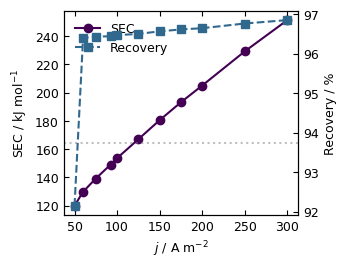

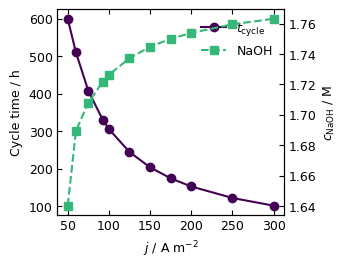

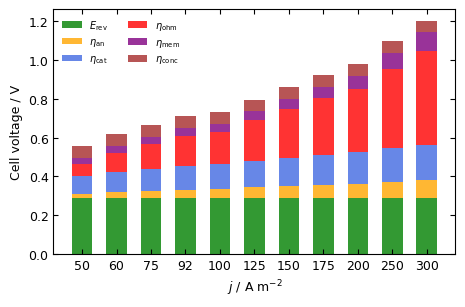

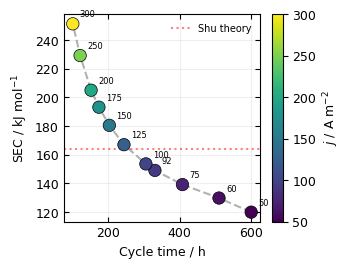

  Done [2491s]

  SENSITIVITY 2: Electrode Gap
  gap=1.0mm | SEC=128 | η_ohm=0.0519V | E=0.6065V
  gap=1.5mm | SEC=133 | η_ohm=0.0778V | E=0.6323V
  gap=2.0mm | SEC=138 | η_ohm=0.1036V | E=0.6581V
  gap=2.5mm | SEC=144 | η_ohm=0.1294V | E=0.6838V
  gap=3.0mm | SEC=149 | η_ohm=0.1551V | E=0.7095V
  gap=4.0mm | SEC=160 | η_ohm=0.2062V | E=0.7606V
  gap=5.0mm | SEC=170 | η_ohm=0.2572V | E=0.8114V
  gap=6.0mm | SEC=181 | η_ohm=0.3079V | E=0.8620V


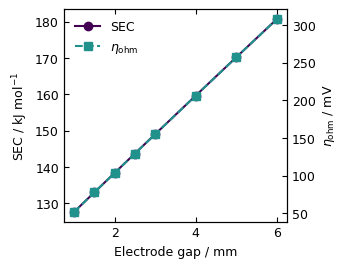

  Done [2111s]

  SENSITIVITY 3: Membrane Thickness
  d_mem=50μm | SEC=148 | η_mem=0.0333V
  d_mem=100μm | SEC=148 | η_mem=0.0352V
  d_mem=127μm | SEC=148 | η_mem=0.0368V
  d_mem=178μm | SEC=149 | η_mem=0.0407V
  d_mem=200μm | SEC=150 | η_mem=0.0428V
  d_mem=250μm | SEC=151 | η_mem=0.0482V
  d_mem=300μm | SEC=152 | η_mem=0.0544V


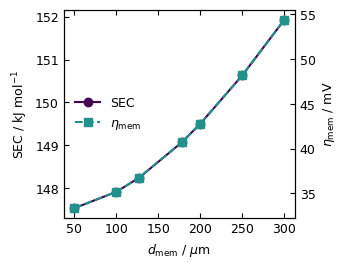

  Done [1836s]

  SENSITIVITY 4: Temperature
  T=5°C | SEC=169 | Recov=94.7% | dT=+1.87K | η2=34.6%
  T=10°C | SEC=161 | Recov=95.4% | dT=+1.65K | η2=35.8%
  T=15°C | SEC=155 | Recov=95.9% | dT=+1.46K | η2=36.8%
  T=20°C | SEC=149 | Recov=96.4% | dT=+1.29K | η2=37.6%
  T=25°C | SEC=145 | Recov=96.9% | dT=+1.20K | η2=38.1%
  T=30°C | SEC=141 | Recov=97.2% | dT=+1.08K | η2=38.6%
  T=35°C | SEC=138 | Recov=97.6% | dT=+1.01K | η2=38.8%
  T=40°C | SEC=135 | Recov=97.8% | dT=+0.91K | η2=39.0%
  T=50°C | SEC=130 | Recov=98.3% | dT=+0.79K | η2=39.0%


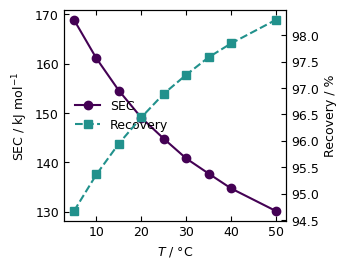

  Done [2340s]

  SENSITIVITY 5: Membrane IEC (Q)
  Q=0.6 | SEC=154 | η_mem=0.0621V
  Q=0.8 | SEC=151 | η_mem=0.0502V
  Q=1.0 | SEC=150 | η_mem=0.0442V
  Q=1.2 | SEC=149 | η_mem=0.0407V
  Q=1.5 | SEC=148 | η_mem=0.0378V
  Q=1.8 | SEC=148 | η_mem=0.0362V
  Q=2.0 | SEC=148 | η_mem=0.0355V
  Q=2.5 | SEC=148 | η_mem=0.0345V


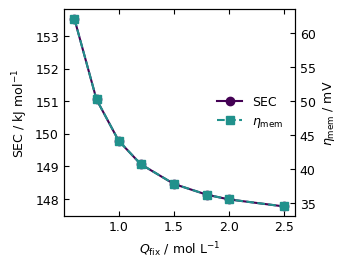

  Done [2097s]

  SENSITIVITY 6: Number of Cells
  N=  3 | SEC=191 | Recov=49.2% | t=600h | P=8.3W
  N=  5 | SEC=149 | Recov=96.4% | t=464h | P=16.4W
  N=  7 | SEC=149 | Recov=96.4% | t=331h | P=22.9W
  N= 10 | SEC=149 | Recov=96.5% | t=232h | P=32.8W
  N= 14 | SEC=149 | Recov=96.5% | t=166h | P=45.8W
  N= 20 | SEC=149 | Recov=96.5% | t=116h | P=65.4W


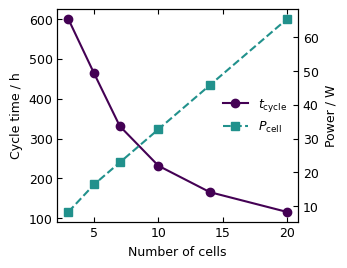

  Done [1490s]

  2D CONTOUR: j × gap → SEC (5×5 grid)
  [1/25] j=50, gap=1.0mm | SEC=111
  [2/25] j=75, gap=1.0mm | SEC=122
  [3/25] j=100, gap=1.0mm | SEC=130
  [4/25] j=150, gap=1.0mm | SEC=146
  [5/25] j=200, gap=1.0mm | SEC=160
  [6/25] j=50, gap=2.0mm | SEC=116
  [7/25] j=75, gap=2.0mm | SEC=130
  [8/25] j=100, gap=2.0mm | SEC=142
  [9/25] j=150, gap=2.0mm | SEC=163
  [10/25] j=200, gap=2.0mm | SEC=183
  [11/25] j=50, gap=3.0mm | SEC=120
  [12/25] j=75, gap=3.0mm | SEC=139
  [13/25] j=100, gap=3.0mm | SEC=154
  [14/25] j=150, gap=3.0mm | SEC=180
  [15/25] j=200, gap=3.0mm | SEC=205
  [16/25] j=50, gap=4.0mm | SEC=124
  [17/25] j=75, gap=4.0mm | SEC=148
  [18/25] j=100, gap=4.0mm | SEC=165
  [19/25] j=150, gap=4.0mm | SEC=197
  [20/25] j=200, gap=4.0mm | SEC=227
  [21/25] j=50, gap=5.0mm | SEC=129
  [22/25] j=75, gap=5.0mm | SEC=157
  [23/25] j=100, gap=5.0mm | SEC=177
  [24/25] j=150, gap=5.0mm | SEC=214
  [25/25] j=200, gap=5.0mm | SEC=249


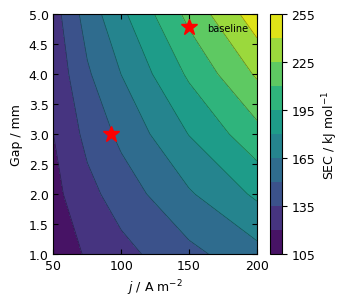

  Done [7085s]

  SENSITIVITY SUMMARY
  Parameter                 Range                      SEC range     Impact
  ──────────────────────────────────────────────────────────────────────
  Current density j         50–300 A/m²           120–251 kJ/mol     STRONG
  Electrode gap             1–6 mm                128–181 kJ/mol     STRONG
  Temperature               5–50 °C               169–130 kJ/mol     STRONG
  N_cell                    3–20                  191–149 kJ/mol  Moderate*
  Membrane IEC (Q)          0.6–2.5 mol/L         154–148 kJ/mol       Weak
  Membrane thickness        50–300 μm             148–152 kJ/mol       WEAK

  * N_cell: SEC constant for N≥5; affects cycle time only
  * Baseline: j=92.4, gap=3mm, d_mem=178μm, T=20°C, Q=1.2, N=7
  * Ref: Shu(2020) theory=164 kJ/mol, experiment=374 kJ/mol

  TOTAL SENSITIVITY TIME: 19450s (324.2 min)


In [ ]:
"""
=============================================================================
 DAC EC Cell — SENSITIVITY ANALYSIS
=============================================================================

"""

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import time as _timer

# ── Fixed feed conditions ────────────────────────────────────────────────
C_NA2CO3_FEED = 0.9501
C_NAOH_RESIDUAL = 0.0998
V_TANK = 200.0
Q_FLOW = 40.0

# ── Helper ───────────────────────────────────────────────────────────────

def run_ec(j_applied=92.4, N_cell=7, A_cell=500e-4,
           d_acid=0.003, d_base=0.003, d_mem=178e-6,
           Q_fix=1.2, kLa=0.05, T_init=293.15, T_amb=293.15,
           n_drag=3.0, pH_stop=5.0, dt_max=10.0):
    """Run EC cell, return results dict or None on failure."""
    try:
        cell = ElectrochemicalCell(
            C_NA2CO3_FEED, C_NAOH_RESIDUAL,
            N_cell=N_cell, A_cell=A_cell, j_applied=j_applied,
            d_acid=d_acid, d_base=d_base, d_mem=d_mem,
            Q_fix=Q_fix, kLa=kLa, T_init=T_init, T_amb=T_amb,
            n_drag=n_drag, pH_stop=pH_stop, dt_max=dt_max,
            V_acid_init=V_TANK, V_base_init=V_TANK,
            Q_flow_total=Q_FLOW)
        cell.solve(verbose=False)
        cell.compute_performance()
        return {
            'SEC': cell.SEC, 'kWh_ton': cell.kWh_t,
            'recovery': cell.recov, 'NaOH_M': cell.c_NaOH_prod[-1],
            'NaOH_purity': cell.NaOH_purity, 'cycle_h': cell.t_actual,
            'E_cell_V': cell.E_avg,
            'eta_ohm_V': np.mean(cell.eta_ohm),
            'eta_mem_V': np.mean(np.abs(cell.eta_mem)),
            'eta_an_V': np.mean(cell.eta_an),
            'eta_cat_V': np.mean(cell.eta_cat),
            'eta_conc_an_V': np.mean(cell.eta_conc_an),
            'eta_conc_cat_V': np.mean(cell.eta_conc_cat),
            'E_rev_V': np.mean(cell.E_rev_act),
            'Na_bal': cell.Na_bal, 'DIC_bal': cell.DIC_bal,
            'eta_2nd': cell.eta_2nd, 'dT': cell.dT_total,
            'P_cell_W': np.mean(cell.power),
            'cell': cell}
    except Exception as e:
        warnings.warn(f"  Failed: {e}")
        return None


# ── Plot setup ───────────────────────────────────────────────────────────
cm = 1/2.54
plt.rcParams.update({'font.size': 9})
_cmap = matplotlib.colormaps["viridis"]


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  1. CURRENT DENSITY j                                                 ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def sens_current_density():
    print("\n" + "="*70)
    print("  SENSITIVITY 1: Current Density j")
    print("="*70)
    t0 = _timer.time()

    j_vals = np.array([50, 60, 75, 92.4, 100, 125, 150, 175, 200, 250, 300])
    keys = ['SEC','recovery','NaOH_M','cycle_h','E_cell_V','eta_2nd',
            'E_rev_V','eta_an_V','eta_cat_V','eta_ohm_V','eta_mem_V',
            'eta_conc_an_V','eta_conc_cat_V']
    data = {k: [] for k in keys}
    j_ok = []

    for j in j_vals:
        r = run_ec(j_applied=j)
        if r:
            j_ok.append(j)
            for k in keys: data[k].append(r[k])
            print(f"  j={j:>6.1f} | SEC={r['SEC']:>4.0f} | Recov={r['recovery']:.1f}% | "
                  f"t={r['cycle_h']:.0f}h | E={r['E_cell_V']:.4f}V | η2={r['eta_2nd']:.1f}%")
        else:
            print(f"  j={j:>6.1f} | FAILED")

    j_ok = np.array(j_ok)
    for k in keys: data[k] = np.array(data[k])
    n = len(j_ok)
    colors = _cmap(np.linspace(0,1,4))

    # Fig 1: SEC + Recovery vs j
    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(j_ok, data['SEC'], 'o-', color=colors[0], label='SEC')
    p2 = ax2.plot(j_ok, data['recovery'], 's--', color=colors[1], label='Recovery')
    ax.axhline(164, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel(r'$j$ / A m$^{-2}$'); ax.set_ylabel('SEC / kJ mol$^{-1}$')
    ax2.set_ylabel('Recovery / %')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False)
    plt.tight_layout(); plt.savefig("fig_sens_j_SEC.svg"); plt.show()

    # Fig 2: Cycle time + NaOH vs j
    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(j_ok, data['cycle_h'], 'o-', color=colors[0], label=r'$t_{\mathrm{cycle}}$')
    p2 = ax2.plot(j_ok, data['NaOH_M'], 's--', color=colors[2], label='NaOH')
    ax.set_xlabel(r'$j$ / A m$^{-2}$'); ax.set_ylabel('Cycle time / h')
    ax2.set_ylabel(r'$c_{\mathrm{NaOH}}$ / M')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False)
    plt.tight_layout(); plt.savefig("fig_sens_j_time.svg"); plt.show()

    # Fig 3: Voltage breakdown stacked bar
    fig, ax = plt.subplots(1,1, figsize=(12*cm,8*cm))
    x = np.arange(n); w = 0.6; b = np.zeros(n)
    parts = [('E_rev_V',r'$E_{\mathrm{rev}}$','green'),
             ('eta_an_V',r'$\eta_{\mathrm{an}}$','orange'),
             ('eta_cat_V',r'$\eta_{\mathrm{cat}}$','royalblue'),
             ('eta_ohm_V',r'$\eta_{\mathrm{ohm}}$','red'),
             ('eta_mem_V',r'$\eta_{\mathrm{mem}}$','purple')]
    for k,lbl,col in parts:
        ax.bar(x, data[k], w, bottom=b, label=lbl, color=col, alpha=0.8)
        b += data[k]
    eta_c = data['eta_conc_an_V'] + data['eta_conc_cat_V']
    ax.bar(x, eta_c, w, bottom=b, label=r'$\eta_{\mathrm{conc}}$', color='brown', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'{j:.0f}' for j in j_ok])
    ax.set_xlabel(r'$j$ / A m$^{-2}$'); ax.set_ylabel('Cell voltage / V')
    ax.legend(fontsize=7, ncol=2, frameon=False)
    ax.tick_params(direction="in", right=True, top=True)
    plt.tight_layout(); plt.savefig("fig_sens_j_voltage.svg"); plt.show()

    # Fig 4: Pareto — SEC vs cycle time
    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    sc = ax.scatter(data['cycle_h'], data['SEC'], c=j_ok, cmap='viridis',
                    s=80, edgecolors='black', linewidth=0.5, zorder=5)
    ax.plot(data['cycle_h'], data['SEC'], 'k--', alpha=0.3)
    for i in range(n):
        ax.annotate(f'{j_ok[i]:.0f}', (data['cycle_h'][i], data['SEC'][i]),
                    textcoords="offset points", xytext=(5,5), fontsize=6)
    plt.colorbar(sc, ax=ax, label=r'$j$ / A m$^{-2}$')
    ax.set_xlabel('Cycle time / h'); ax.set_ylabel('SEC / kJ mol$^{-1}$')
    ax.axhline(164, color='red', ls=':', alpha=0.5, label='Shu theory')
    ax.legend(fontsize=7, frameon=False); ax.grid(True, alpha=0.2)
    ax.tick_params(direction="in", right=True, top=True)
    plt.tight_layout(); plt.savefig("fig_sens_j_pareto.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return j_ok, data


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  2. ELECTRODE GAP                                                     ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def sens_gap():
    print("\n" + "="*70)
    print("  SENSITIVITY 2: Electrode Gap")
    print("="*70)
    t0 = _timer.time()

    gap_mm = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0])
    SEC, eta_ohm, E_cell = [], [], []
    g_ok = []

    for g in gap_mm:
        r = run_ec(d_acid=g*1e-3, d_base=g*1e-3)
        if r:
            g_ok.append(g); SEC.append(r['SEC'])
            eta_ohm.append(r['eta_ohm_V']); E_cell.append(r['E_cell_V'])
            print(f"  gap={g:.1f}mm | SEC={r['SEC']:.0f} | η_ohm={r['eta_ohm_V']:.4f}V | E={r['E_cell_V']:.4f}V")

    g_ok = np.array(g_ok); SEC = np.array(SEC); eta_ohm = np.array(eta_ohm)
    colors = _cmap(np.linspace(0,1,3))

    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(g_ok, SEC, 'o-', color=colors[0], label='SEC')
    p2 = ax2.plot(g_ok, eta_ohm*1e3, 's--', color=colors[1], label=r'$\eta_{\mathrm{ohm}}$')
    ax.set_xlabel('Electrode gap / mm'); ax.set_ylabel('SEC / kJ mol$^{-1}$')
    ax2.set_ylabel(r'$\eta_{\mathrm{ohm}}$ / mV')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False, loc="upper left")
    plt.tight_layout(); plt.savefig("fig_sens_gap.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return g_ok, {'SEC': SEC, 'eta_ohm': eta_ohm}


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  3. MEMBRANE THICKNESS                                                ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def sens_membrane():
    print("\n" + "="*70)
    print("  SENSITIVITY 3: Membrane Thickness")
    print("="*70)
    t0 = _timer.time()

    d_um = np.array([50, 100, 127, 178, 200, 250, 300])
    SEC, eta_mem = [], []
    d_ok = []

    for d in d_um:
        r = run_ec(d_mem=d*1e-6)
        if r:
            d_ok.append(d); SEC.append(r['SEC']); eta_mem.append(r['eta_mem_V'])
            print(f"  d_mem={d:.0f}μm | SEC={r['SEC']:.0f} | η_mem={r['eta_mem_V']:.4f}V")

    d_ok = np.array(d_ok); SEC = np.array(SEC); eta_mem = np.array(eta_mem)
    colors = _cmap(np.linspace(0,1,3))

    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(d_ok, SEC, 'o-', color=colors[0], label='SEC')
    p2 = ax2.plot(d_ok, eta_mem*1e3, 's--', color=colors[1], label=r'$\eta_{\mathrm{mem}}$')
    ax.set_xlabel(r'$d_{\mathrm{mem}}$ / $\mu$m'); ax.set_ylabel('SEC / kJ mol$^{-1}$')
    ax2.set_ylabel(r'$\eta_{\mathrm{mem}}$ / mV')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False, loc="center left")
    plt.tight_layout(); plt.savefig("fig_sens_dmem.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return d_ok, {'SEC': SEC, 'eta_mem': eta_mem}


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  4. TEMPERATURE                                                       ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def sens_temperature():
    print("\n" + "="*70)
    print("  SENSITIVITY 4: Temperature")
    print("="*70)
    t0 = _timer.time()

    T_C = np.array([5, 10, 15, 20, 25, 30, 35, 40, 50])
    SEC, recov, eta_2nd, dT = [], [], [], []
    T_ok = []

    for T in T_C:
        r = run_ec(T_init=T+273.15, T_amb=T+273.15)
        if r:
            T_ok.append(T); SEC.append(r['SEC']); recov.append(r['recovery'])
            eta_2nd.append(r['eta_2nd']); dT.append(r['dT'])
            print(f"  T={T:.0f}°C | SEC={r['SEC']:.0f} | Recov={r['recovery']:.1f}% | "
                  f"dT={r['dT']:+.2f}K | η2={r['eta_2nd']:.1f}%")

    T_ok = np.array(T_ok); SEC = np.array(SEC); recov = np.array(recov)
    colors = _cmap(np.linspace(0,1,3))

    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(T_ok, SEC, 'o-', color=colors[0], label='SEC')
    p2 = ax2.plot(T_ok, recov, 's--', color=colors[1], label='Recovery')
    ax.set_xlabel(r'$T$ / °C'); ax.set_ylabel('SEC / kJ mol$^{-1}$')
    ax2.set_ylabel('Recovery / %')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False, loc="center left")
    plt.tight_layout(); plt.savefig("fig_sens_T.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return T_ok, {'SEC': SEC, 'recovery': recov, 'eta_2nd': np.array(eta_2nd)}


# ╔══════════════════════════════════════════════════��════════════════════╗
# ║  5. MEMBRANE IEC (Q)                                                  ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def sens_Qfix():
    print("\n" + "="*70)
    print("  SENSITIVITY 5: Membrane IEC (Q)")
    print("="*70)
    t0 = _timer.time()

    Q_vals = np.array([0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5])
    SEC, eta_mem = [], []
    Q_ok = []

    for Q in Q_vals:
        r = run_ec(Q_fix=Q)
        if r:
            Q_ok.append(Q); SEC.append(r['SEC']); eta_mem.append(r['eta_mem_V'])
            print(f"  Q={Q:.1f} | SEC={r['SEC']:.0f} | η_mem={r['eta_mem_V']:.4f}V")

    Q_ok = np.array(Q_ok); SEC = np.array(SEC); eta_mem = np.array(eta_mem)
    colors = _cmap(np.linspace(0,1,3))

    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(Q_ok, SEC, 'o-', color=colors[0], label='SEC')
    p2 = ax2.plot(Q_ok, eta_mem*1e3, 's--', color=colors[1], label=r'$\eta_{\mathrm{mem}}$')
    ax.set_xlabel(r'$Q_{\mathrm{fix}}$ / mol L$^{-1}$'); ax.set_ylabel('SEC / kJ mol$^{-1}$')
    ax2.set_ylabel(r'$\eta_{\mathrm{mem}}$ / mV')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False, loc="center right")
    plt.tight_layout(); plt.savefig("fig_sens_Q.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return Q_ok, {'SEC': SEC, 'eta_mem': eta_mem}


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  6. NUMBER OF CELLS                                                   ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def sens_Ncell():
    print("\n" + "="*70)
    print("  SENSITIVITY 6: Number of Cells")
    print("="*70)
    t0 = _timer.time()

    N_vals = np.array([3, 5, 7, 10, 14, 20])
    SEC, recov, t_h, P_W = [], [], [], []
    N_ok = []

    for N in N_vals:
        r = run_ec(N_cell=int(N))
        if r:
            N_ok.append(int(N)); SEC.append(r['SEC']); recov.append(r['recovery'])
            t_h.append(r['cycle_h']); P_W.append(r['P_cell_W'])
            print(f"  N={int(N):>3d} | SEC={r['SEC']:.0f} | Recov={r['recovery']:.1f}% | "
                  f"t={r['cycle_h']:.0f}h | P={r['P_cell_W']:.1f}W")

    N_ok = np.array(N_ok); t_h = np.array(t_h); P_W = np.array(P_W)
    colors = _cmap(np.linspace(0,1,3))

    fig, ax = plt.subplots(1,1, figsize=(9*cm,7*cm))
    ax2 = ax.twinx()
    p1 = ax.plot(N_ok, t_h, 'o-', color=colors[0], label=r'$t_{\mathrm{cycle}}$')
    p2 = ax2.plot(N_ok, P_W, 's--', color=colors[1], label=r'$P_{\mathrm{cell}}$')
    ax.set_xlabel('Number of cells'); ax.set_ylabel('Cycle time / h')
    ax2.set_ylabel('Power / W')
    ax.tick_params(direction="in", right=False, top=True)
    ax2.tick_params(direction="in", right=True, top=True)
    ax.legend(p1+p2, [l.get_label() for l in p1+p2], frameon=False, loc="center right")
    plt.tight_layout(); plt.savefig("fig_sens_Ncell.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return N_ok, {'SEC': np.array(SEC), 'cycle_h': t_h, 'P_W': P_W}


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  7. 2D CONTOUR: j × gap → SEC (reduced 5×5 grid)                      ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def contour_j_gap():
    print("\n" + "="*70)
    print("  2D CONTOUR: j × gap → SEC (5×5 grid)")
    print("="*70)
    t0 = _timer.time()

    j_vals = np.array([50, 75, 100, 150, 200])
    g_vals = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
    SEC_grid = np.full((len(g_vals), len(j_vals)), np.nan)
    total = len(j_vals)*len(g_vals); count = 0

    for ig, g in enumerate(g_vals):
        for ij, j in enumerate(j_vals):
            count += 1
            r = run_ec(j_applied=j, d_acid=g*1e-3, d_base=g*1e-3)
            if r:
                SEC_grid[ig, ij] = r['SEC']
                print(f"  [{count}/{total}] j={j:.0f}, gap={g:.1f}mm | SEC={r['SEC']:.0f}")
            else:
                print(f"  [{count}/{total}] FAILED")

    fig, ax = plt.subplots(1,1, figsize=(9*cm,8*cm))
    cs = ax.contourf(j_vals, g_vals, SEC_grid, levels=12, cmap="viridis")
    ax.contour(j_vals, g_vals, SEC_grid, levels=12, colors='k', linewidths=0.5, alpha=0.4)
    ax.plot(92.4, 3.0, 'r*', ms=12, label='baseline')
    plt.colorbar(cs, ax=ax, label='SEC / kJ mol$^{-1}$')
    ax.set_xlabel(r'$j$ / A m$^{-2}$'); ax.set_ylabel('Gap / mm')
    ax.legend(frameon=False, fontsize=7)
    ax.tick_params(direction="in", right=True, top=True)
    plt.tight_layout(); plt.savefig("fig_contour_j_gap.svg"); plt.show()

    print(f"  Done [{_timer.time()-t0:.0f}s]")
    return j_vals, g_vals, SEC_grid


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  SUMMARY TABLE (from already-computed results)                        ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def print_sensitivity_summary():
    """Print summary table — call after running all sweeps."""
    print("\n" + "="*75)
    print("  SENSITIVITY SUMMARY")
    print("="*75)
    print(f"  {'Parameter':<25s} {'Range':<20s} {'SEC range':>15s} {'Impact':>10s}")
    print(f"  {'─'*70}")
    rows = [
        ("Current density j",    "50–300 A/m²",    "120–251 kJ/mol", "STRONG"),
        ("Electrode gap",        "1–6 mm",         "128–181 kJ/mol", "STRONG"),
        ("Temperature",          "5–50 °C",        "169–130 kJ/mol", "STRONG"),
        ("N_cell",               "3–20",           "191–149 kJ/mol", "Moderate*"),
        ("Membrane IEC (Q)",     "0.6–2.5 mol/L",  "154–148 kJ/mol", "Weak"),
        ("Membrane thickness",   "50–300 μm",      "148–152 kJ/mol", "WEAK"),
    ]
    for name, rng, sec, imp in rows:
        print(f"  {name:<25s} {rng:<20s} {sec:>15s} {imp:>10s}")
    print(f"\n  * N_cell: SEC constant for N≥5; affects cycle time only")
    print(f"  * Baseline: j=92.4, gap=3mm, d_mem=178μm, T=20°C, Q=1.2, N=7")
    print(f"  * Ref: Shu(2020) theory=164 kJ/mol, experiment=374 kJ/mol")
    print("="*75)


# ╔═══════════════════════════════════════════════════════════════════════╗
# ║  RUN ALL SENSITIVITY                                                  ║
# ╚═══════════════════════════════════════════════════════════════════════╝

def run_all_sensitivity():
    t0 = _timer.time()
    print("\n" + "="*80)
    print("  DAC V13.2 — EC CELL SENSITIVITY ANALYSIS")
    print(f"  Feed: {C_NA2CO3_FEED:.4f}M Na2CO3 + {C_NAOH_RESIDUAL:.4f}M NaOH")
    print("="*80)

    r1 = sens_current_density()
    r2 = sens_gap()
    r3 = sens_membrane()
    r4 = sens_temperature()
    r5 = sens_Qfix()
    r6 = sens_Ncell()
    r7 = contour_j_gap()
    print_sensitivity_summary()

    print(f"\n  TOTAL SENSITIVITY TIME: {_timer.time()-t0:.0f}s ({(_timer.time()-t0)/60:.1f} min)")
    return {'j': r1, 'gap': r2, 'dmem': r3, 'T': r4, 'Q': r5, 'N': r6, 'contour': r7}
sens_results = run_all_sensitivity()


  Absorber: 200L, 40L/min
    Pass   500: NaOH=1.7468, Na2CO3=0.1266, t=41.7h
    Pass  1000: NaOH=1.4956, Na2CO3=0.2522, t=83.3h
    Pass  1500: NaOH=1.2467, Na2CO3=0.3767, t=125.0h
    Pass  2000: NaOH=1.0008, Na2CO3=0.4996, t=166.7h
    Pass  2500: NaOH=0.7589, Na2CO3=0.6206, t=208.3h
    Pass  3000: NaOH=0.5228, Na2CO3=0.7386, t=250.0h
    Pass  3500: NaOH=0.2961, Na2CO3=0.8519, t=291.7h

  ABSORBER: 3973 passes | 331.1h (13.8d)
    NaOH: 2.000 -> 0.0998M
    Na2CO3: 0 -> 0.9501M
    CO2: 190.0 mol (8361g)

  EC Cell V13.2: 7x500cm2 | j=92.4A/m2 | pH_stop=5.0
    Feed: 0.9501M Na2CO3 + 0.0998M NaOH
    V_acid=199.2L | V_base=200.6L (variable)
    CEM: Nernst-Planck, d=178um, Q=1.2
    -> pH-stop at 331.3h


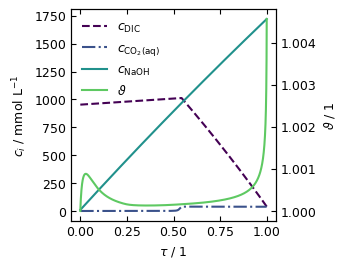

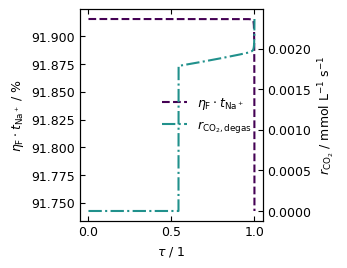


  CO2: 183.3 mol (8065 g) | Recovery: 96.5%
  NaOH: 1.7218 M | SEC: 149 kJ/mol
  E_cell avg: 0.7113 V | t = 331.3 h


In [ ]:
"""
Standard case characteristic graphs for the DAC Electrochemical Cell

"""

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ── Solve ────────────────────────────────────────────────────────────────
absorber = AbsorberCase1()
absorber.run(verbose=True)
absorber.summary()

cell = ElectrochemicalCell(
    absorber.c_Na2CO3_final, absorber.c_NaOH_final,
    N_cell=7, A_cell=500e-4, j_applied=92.4,
    V_acid_init=200.0, V_base_init=200.0,
    Q_flow_total=40.0, d_acid=0.003, d_base=0.003
)
cell.solve(verbose=True)
cell.compute_performance()

# Dimensionless time: tau = t / t_final
tau = cell.t_eval / cell.t_eval[-1]

# Dimensionless temperature: theta = T / T_init
theta = cell.T_arr / cell.T_init

# ── Plot style  ───────────────────────
cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 5))
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
cm = 1 / 2.54
plt.rcParams.update({'font.size': 9})

# ═════════════════════════════════════════════════════════════════════════
# GRAPH 1: Species concentrations + dimensionless temperature vs tau
# ═════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(1, 1, figsize=(9*cm, 7*cm))
ax2 = ax.twinx()

plt1 = ax.plot(tau, cell.C_DIC * 1e3,
               label=r"$c_{\mathrm{DIC}}$",
               color=colors[0], linestyle=linestyles[1])
plt2 = ax.plot(tau, cell.c_CO2aq * 1e3,
               label=r"$c_{\mathrm{CO_2(aq)}}$",
               color=colors[1], linestyle=linestyles[2])
plt3 = ax.plot(tau, cell.c_NaOH_prod * 1e3,
               label=r"$c_{\mathrm{NaOH}}$",
               color=colors[2], linestyle=linestyles[0])
plt4 = ax2.plot(tau, theta,
                label=r"$\vartheta$",
                color=colors[3], linestyle=linestyles[0])

ax.set_xlim(-0.05, 1.05)
ax.set_xlabel(r"$\tau$ / 1")
ax.set_ylabel(r"$c_i$ / mmol L$^{-1}$")
ax2.set_ylabel(r"$\vartheta$ / 1")
ax.tick_params(direction="in", axis='both', which='major', right=False, top=True)
ax2.tick_params(direction="in", axis='both', which='major', right=True, top=True)

plts = plt1 + plt2 + plt3 + plt4
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="best", frameon=False)
plt.tight_layout()
plt.savefig("ec_standard_c_theta.svg")
plt.show()

# ═════════════════════════════════════════════════════════════════════════
# GRAPH 2: Faradaic efficiency × transport number + CO2 degas rate vs tau
# ═════════════════════════════════════════════════════════════════════════

colors2 = cmap(np.linspace(0, 1, 3))

fig, ax = plt.subplots(1, 1, figsize=(9*cm, 7*cm))
ax2 = ax.twinx()

plt1 = ax.plot(tau, cell.eta_F_eff * 100,
               label=r"$\eta_{\mathrm{F}} \cdot t_{\mathrm{Na^+}}$",
               color=colors2[0], linestyle=linestyles[1])
plt2 = ax2.plot(tau, cell.r_deg * 1e3,
                label=r"$r_{\mathrm{CO_2,degas}}$",
                color=colors2[1], linestyle=linestyles[2])

ax.set_xlim(-0.05, 1.05)
ax.set_xlabel(r"$\tau$ / 1")
ax.set_ylabel(r"$\eta_{\mathrm{F}} \cdot t_{\mathrm{Na^+}}$ / %")
ax2.set_ylabel(r"$r_{\mathrm{CO_2}}$ / mmol L$^{-1}$ s$^{-1}$")
ax.tick_params(direction="in", axis='both', which='major', right=False, top=True)
ax2.tick_params(direction="in", axis='both', which='major', right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="right", frameon=False)
plt.tight_layout()
plt.savefig("ec_standard_eta_r_degas.svg")
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────
print(f"\n  CO2: {cell.m_CO2_actual:.1f} mol ({cell.m_CO2_actual*44:.0f} g) | Recovery: {cell.recov:.1f}%")
print(f"  NaOH: {cell.c_NaOH_prod[-1]:.4f} M | SEC: {cell.SEC:.0f} kJ/mol")
print(f"  E_cell avg: {cell.E_avg:.4f} V | t = {cell.t_actual:.1f} h")